In [572]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from numba import njit
from typing import Tuple
from numpy.linalg import inv

# Configuração de estilo para os gráficos ficarem mais legíveis
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Apresentação do Problema

O problema central abordado é o rastreamento da posição de um objeto móvel (pedestre ou robô) em um plano bidimensional (OXY), utilizando medições de distância (range) obtidas a partir de estações base fixas.

O principal desafio reside na não-linearidade do modelo de observação. A distância medida entre o objeto e uma estação base não é uma função linear das coordenadas $(x, y)$ do objeto, o que impede o uso do Filtro de Kalman clássico. Para contornar isso, utiliza-se o EKF, que realiza uma linearização local por meio de expansões em série de Taylor.

In [573]:
# Posição das estações base (X,Y).
S1 = np.array([0,0]).T
S2 = np.array([600,600]).T
S3 = np.array([0,600]).T
S4 = np.array([600,0]).T

#Variável para iterar sobre elas
bases = np.array([S1,S2,S3,S4])

# 2. Modelo de Observação Não-Linear

A detecção do objeto é utilizada com base na distância calculada por cada uma das 4 estações bases ($S_1$, $S_2$, $S_3$ e $S_4$). Resolvendo, portanto o sistema de equações dadas por ela, teremos a posição $P = [x,y,z]^T$ do robô.

## 2.1. Cálculo das Distâncias

A distância capturada por cada sensor é a distância euclidiana do ponto a uma à estação base $S_i$ ($d_{i}$) ponto somado com um ruído $\mathbf{v}_i$ de medição.

$$d_{i}(t)=\sqrt{(X_{i}-x(t))^{2}+(Y_{i}-y(t))^{2}}+v_{i}(t)$$

In [574]:
def dist(point_a: np.ndarray, point_b: np.ndarray) -> float:
    """
    Calcula a distância euclidiana entre dois pontos n-dimensionais.
    """
    return np.linalg.norm(point_a - point_b)

In [575]:
#Exemplo:
P1 = np.array([0,10]).T
P2 = np.array([10,0]).T
dist(P1,P2)

14.142135623730951

Podemos representar o vetor de medições $\mathbf{z}(t)$ como a soma do vetor de distâncias teóricas (função não-linear do estado) e o vetor de ruído aleatório $\mathbf{v}(t)$:$$\mathbf{z}(t) = \begin{bmatrix} \sqrt{(X_{1}-x(t))^{2}+(Y_{1}-y(t))^{2}} \\ \sqrt{(X_{2}-x(t))^{2}+(Y_{2}-y(t))^{2}} \\ \sqrt{(X_{3}-x(t))^{2}+(Y_{3}-y(t))^{2}} \\ \sqrt{(X_{4}-x(t))^{2}+(Y_{4}-y(t))^{2}} \end{bmatrix} + \begin{bmatrix} v_{1}(t) \\ v_{2}(t) \\ v_{3}(t) \\ v_{4}(t) \end{bmatrix}$$Ou, de forma compacta:$$\mathbf{z}(t) = \mathbf{h}(\mathbf{x}(t)) + \mathbf{v}(t)$$



In [576]:
def h_obs(pos: np.ndarray, bases: np.ndarray) -> np.ndarray:
    """
    Calcula o vetor de observação h(x) (distâncias teóricas).
    
    Retorna um vetor coluna (N, 1) contendo as distâncias euclidianas 
    entre a posição atual e as estações base.
    """
    # Cálculo vetorizado das distâncias (Norma L2 por linha)
    z = np.linalg.norm(bases - pos, axis=1)
    
    return z.reshape(-1, 1)

In [577]:
# Exemplo
pos = np.array([50,50]).T

print("Valor observado: \n",h_obs(pos, bases))

Valor observado: 
 [[ 70.71067812]
 [777.81745931]
 [552.26805086]
 [552.26805086]]


Como temos 4 observações, cada qual com um desvio padrão diferente, assumindo que são independentes uma das outras a leitura, podemos partir do pressuposto que R é uma diagonal

$$R = \begin{bmatrix} \sigma_1^2 & 0 & 0 & 0 \\ 0 & \sigma_2^2 & 0 & 0 \\ 0 & 0 & \sigma_3^2 & 0 \\ 0 & 0 & 0 & \sigma_4^2 \end{bmatrix}$$

In [578]:
# Gerar valores estocásticos
def create_cov(sigmas: np.ndarray) -> np.ndarray:
    """
    Gera uma matriz de covariância diagonal a partir de uma lista de desvios padrões.
    Útil para inicializar matrizes de ruído independentes (ex: R ou Q diagonal).
    """
    # Transformamos os desvios em variâncias (quadrado) e criamos a diagonal 
    return np.diag(np.square(sigmas))

def get_noise_vec(R: np.ndarray) -> np.ndarray:
    """
    Gera uma amostra de vetor de ruído branco (média zero) baseado na matriz de covariância.
    Retorna um vetor coluna (N, 1).
    """
    # Determina o número de sensores (dimensão da matriz)
    n = R.shape[0]
    
    # Gera o ruído com média zero para todos os sensores
    v = np.random.multivariate_normal(np.zeros(n), R)
    
    # Retorna como vetor coluna (n, 1) para manter o padrão do filtro
    return v.reshape(-1, 1)

In [579]:
# Exemplo
# Variâncias
dp1 = 0.1
dp2 = 0.1
dp3 = 0.1
dp4 = 0.4 

# Ponto atual como vetor coluna (2x1)
pos = np.array([[50], [120]])

# Pegando a matriz R (passando apenas os desvios)
R = create_cov([dp1,dp2,dp3,dp4])

print("Matriz R: \n", R)

# Recuperando o vetor de erros aleatórios (4x1)
v_t = get_noise_vec(R)
print("\nMédia do vetor de erros: \n", np.mean(v_t,axis=1,keepdims=True))

# Medição final ruidosa (transpondo pos para broadcasting)
z_t = h_obs(pos.T, bases) + v_t

print("\nValor observado final: \n",z_t)

Matriz R: 
 [[0.01 0.   0.   0.  ]
 [0.   0.01 0.   0.  ]
 [0.   0.   0.01 0.  ]
 [0.   0.   0.   0.16]]

Média do vetor de erros: 
 [[ 0.08365089]
 [-0.15409789]
 [-0.20014551]
 [-0.01809622]]

Valor observado final: 
 [[130.08365089]
 [729.84590211]
 [482.39699497]
 [562.92062158]]


# 3. Modelo de Transição de Estados 
## 3.1. O que é um Modelo de Transição de Estados?

O **Modelo de Transição de Estados** (também chamado de Modelo de Processo ou Modelo Dinâmico) é o "motor físico" do Filtro de Kalman. Ele descreve matematicamente a evolução do sistema ao longo do tempo, ou seja, dita as regras de como o objeto rastreado se move do instante passado ($k-1$) para o instante atual ($k$), independentemente do que os sensores estão medindo.

Enquanto o *Modelo de Observação* traduz o que está acontecendo no espaço dos sensores (as distâncias até as antenas), o *Modelo de Transição* usa as leis da cinemática para prever o comportamento natural do a etapa de atualização.

## 3.2. Modelo de Posição-Velocidade (PV)

O modelo de Posição-Velocidade (PV), frequentemente chamado de Modelo de Velocidade Constante, é utilizado para descrever a cinemática de um alvo assumindo que, entre dois instantes de tempo, sua velocidade se mantém constante. Qualquer variação nessa velocidade (ou seja, acelerações ou manobras do objeto) não é modelada explicitamente de forma determinística, mas sim tratada como um distúrbio aleatório englobado no ruído do processo.

Este modelo é altamente eficaz para o rastreamento de objetos que descrevem trajetórias predominantemente retilíneas e uniformes.

### Vetor de Estado

Para um sistema bidimensional (2D), o vetor de estado consolida as informações espaciais do objeto. Ele possui dimensão $4 \times 1$, sendo composto pelas coordenadas de posição ($p_x, p_y$) e suas respectivas componentes de velocidade ($v_x, v_y$):

$$x = \begin{bmatrix} p_x \\ p_y \\ v_x \\ v_y \end{bmatrix}$$

### 3.2.1. Formulação no Tempo Contínuo

Para compreender a física do sistema, inicialmente modelamos a cinemática no domínio do tempo contínuo. A dinâmica do estado é governada pela equação diferencial linear:

$$\dot{x}(t) = A x(t) + w(t)$$

Onde $\dot{x}(t)$ é a derivada do estado no tempo. Sabemos pela física clássica que a derivada da posição é a velocidade ($\dot{p} = v$), e como assumimos velocidade constante, a derivada da velocidade seria teoricamente nula ($\dot{v} = 0$), sendo afetada apenas pelo ruído contínuo $w(t)$ (que atua como uma aceleração aleatória).

Assim, a **Matriz Dinâmica do Sistema Contínuo ($A$)** é definida como:

$$A = \begin{bmatrix} 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \end{bmatrix}$$

A **Matriz de Covariância do Ruído do Processo Contínuo ($Q_c$)** modela a densidade espectral dessa aceleração aleatória. 

$$Q_c = \begin{bmatrix} q_1 & 0 & 0 & 0 \\ 0 & q_2 & 0 & 0 \\ 0 & 0 & q_3 & 0 \\ 0 & 0 & 0 & q_4 \end{bmatrix}$$

In [580]:
# Exemplo fictício se as incertezas em X e Y fossem independentes
desvios_proc = [0.1, 0.1, 0.5, 0.5] 
Q = create_cov(variancas_processo)
w_k = get_noise_vec(Q_diagonal)

print("Matriz Q: \n",Q,"\n\n\n Vetor W: \n",w_k)

Matriz Q: 
 [[0.01 0.   0.   0.  ]
 [0.   0.01 0.   0.  ]
 [0.   0.   0.25 0.  ]
 [0.   0.   0.   0.25]] 


 Vetor W: 
 [[ 0.        ]
 [ 0.        ]
 [ 0.04321406]
 [-0.15213621]]


### 3.2.2. Discretização do Modelo

Como o Filtro de Kalman opera em processadores digitais lidando com dados amostrados por sensores, precisamos transpor o modelo contínuo para o domínio discreto, considerando um intervalo de amostragem $\Delta t$.

#### Matriz de Transição de Estado Discreta ($F$)
A matriz de transição de estado discreta $F$ é obtida a partir da matriz contínua $A$ através da relação exponencial da matriz: $F = e^{A \Delta t}$. Para este modelo específico, a expansão de Taylor resulta exatamente na aplicação das leis da cinemática clássica ($p_k = p_{k-1} + v_{k-1}\Delta t$):

$$F = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

#### Matriz de Covariância do Ruído do Processo Discreta ($Q$)
A matriz discreta $Q$ não é uma simples substituição direta. Ela é obtida integrando o efeito do ruído contínuo ($Q_c$) ao longo de todo o intervalo de amostragem $\Delta t$, utilizando a equação:

$$Q = \int_{0}^{\Delta t} F(\tau) Q_c F(\tau)^T d\tau$$

Ao resolvermos essa integral, obtemos o impacto físico cumulativo de acelerações desconhecidas sobre a posição e a velocidade. A incerteza projetada no estado discreto torna-se:

$$Q = \begin{bmatrix} q_1 \Delta t + q_3 \frac{\Delta t^3}{3} & 0 & q_3 \frac{\Delta t^2}{2} & 0 \\ 0 & q_2 \Delta t + q_4 \frac{\Delta t^3}{3} & 0 & q_4 \frac{\Delta t^2}{2} \\ q_3 \frac{\Delta t^2}{2} & 0 & q_3 \Delta t & 0 \\ 0 & q_4 \frac{\Delta t^2}{2} & 0 & q_4 \Delta t \end{bmatrix}$$

Essa formulação rigorosa garante que o filtro compreenda a relação física cruzada entre as variáveis: um distúrbio introduzido na velocidade ao longo do tempo $\Delta t$ afetará inexoravelmente a incerteza da posição futura, o que se reflete diretamente nos termos fora da diagonal principal de $Q$.

In [581]:
@njit
def get_Q_disc_PV(q_diag: list, dt: float) -> np.ndarray:
    """
    q_diag: lista com as variâncias contínuas [q1(px), q2(py), q3(vx), q4(vy)]
    dt: delta t (tempo de amostragem)
    """
    q1, q2, q3, q4 = q_diag
    
    Q = np.zeros((4, 4))
    
    # Eixo X
    Q[0, 0] = q1 * dt + q3 * (dt**3) / 3.0
    Q[0, 2] = q3 * (dt**2) / 2.0
    Q[2, 0] = Q[0, 2]
    Q[2, 2] = q3 * dt
    
    # Eixo Y
    Q[1, 1] = q2 * dt + q4 * (dt**3) / 3.0
    Q[1, 3] = q4 * (dt**2) / 2.0
    Q[3, 1] = Q[1, 3]
    Q[3, 3] = q4 * dt
    
    return Q

In [582]:
# Exemplo
dT = 1e-2

# Variâncias do ruído contínuo
q1 = 0.1
q2 = 0.1
q3 = 0.1
q4 = 0.1

# Criando matriz Q discreta:
Q_disc = get_Q_disc_PV([q1, q2, q3, q4], dT)

# Definindo a Matriz Contínua A 
A = np.array([[0, 0, 1, 0],
              [0, 0, 0, 1],
              [0, 0, 0, 0],
              [0, 0, 0, 0]])

# Gerando a Matriz de Transição F (e^{A*dT})
F = expm(A * dT)

# Resultados
print("Matriz Contínua A:\n", A)
print("\nMatriz Discreta de Transição F:\n", F)
print("\nMatriz de Covariância do Ruído de Processo Q_disc:\n", Q_disc)

Matriz Contínua A:
 [[0 0 1 0]
 [0 0 0 1]
 [0 0 0 0]
 [0 0 0 0]]

Matriz Discreta de Transição F:
 [[1.   0.   0.01 0.  ]
 [0.   1.   0.   0.01]
 [0.   0.   1.   0.  ]
 [0.   0.   0.   1.  ]]

Matriz de Covariância do Ruído de Processo Q_disc:
 [[1.00003333e-03 0.00000000e+00 5.00000000e-06 0.00000000e+00]
 [0.00000000e+00 1.00003333e-03 0.00000000e+00 5.00000000e-06]
 [5.00000000e-06 0.00000000e+00 1.00000000e-03 0.00000000e+00]
 [0.00000000e+00 5.00000000e-06 0.00000000e+00 1.00000000e-03]]


## 3.3. Modelo de Posição-Velocidade-Aceleração (PVA)

O modelo de Posição-Velocidade-Aceleração (PVA), também conhecido como Modelo de Aceleração Constante, é utilizado para sistemas cuja dinâmica envolve manobras intencionais, curvas acentuadas ou forças consistentes ao longo do tempo. Diferente do modelo PV — onde a aceleração é tratada apenas como um ruído aleatório —, o modelo PVA eleva a aceleração à categoria de **variável de estado**, estimando-a ativamente.

Neste modelo, assume-se que a aceleração se mantém constante entre as amostragens. A incerteza (ruído do processo) deixa de ser a própria aceleração e passa a ser a **variação da aceleração** (conhecida na física como *jerk* ou solavanco). Este modelo é ideal para o rastreamento de alvos altamente ágeis, como drones e mísseis.

### Vetor de Estado

Para um sistema bidimensional (2D), o vetor de estado agora expande sua dimensão para $6 \times 1$. Ele incorpora as coordenadas de posição ($p_x, p_y$), velocidade ($v_x, v_y$) e aceleração ($a_x, a_y$):

$$x = \begin{bmatrix} p_x \\ p_y \\ v_x \\ v_y \\ a_x \\ a_y \end{bmatrix}$$

### 3.3.1. Formulação no Tempo Contínuo

No domínio do tempo contínuo, a equação diferencial $\dot{x}(t) = A x(t) + w(t)$ dita o comportamento do sistema. Pela cinemática, sabemos que $\dot{p} = v$, $\dot{v} = a$, e assumimos que a derivada da aceleração é nula ($\dot{a} = 0$), sendo perturbada apenas pelo ruído branco contínuo $w(t)$.

A **Matriz Dinâmica do Sistema Contínuo ($A$)** de dimensão $6 \times 6$ é definida como:

$$A = \begin{bmatrix} 
0 & 0 & 1 & 0 & 0 & 0 \\ 
0 & 0 & 0 & 1 & 0 & 0 \\ 
0 & 0 & 0 & 0 & 1 & 0 \\ 
0 & 0 & 0 & 0 & 0 & 1 \\ 
0 & 0 & 0 & 0 & 0 & 0 \\ 
0 & 0 & 0 & 0 & 0 & 0 
\end{bmatrix}$$

Na formulação mais abrangente deste modelo, assumimos que o ruído do processo pode injetar incertezas independentes em todos os estados do sistema. Assim, a **Matriz de Covariância do Ruído do Processo Contínuo ($Q_c$)** é definida como uma matriz diagonal contendo as variâncias espectrais específicas de cada variável:

$$Q_c = \begin{bmatrix} 
q_1 & 0 & 0 & 0 & 0 & 0 \\ 
0 & q_2 & 0 & 0 & 0 & 0 \\ 
0 & 0 & q_3 & 0 & 0 & 0 \\ 
0 & 0 & 0 & q_4 & 0 & 0 \\ 
0 & 0 & 0 & 0 & q_5 & 0 \\ 
0 & 0 & 0 & 0 & 0 & q_6 
\end{bmatrix}$$

Onde:
* $q_1, q_2$: Incertezas não modeladas injetadas diretamente na posição ($X$ e $Y$).
* $q_3, q_4$: Incertezas injetadas na velocidade ($X$ e $Y$).
* $q_5, q_6$: Incertezas injetadas na aceleração, ou solavanco ($X$ e $Y$).

### 3.3.2. Discretização para o EKF

Para aplicar este modelo em processadores digitais com período de amostragem $\Delta t$, convertemos o sistema contínuo para o discreto.

#### Matriz de Transição de Estado Discreta ($F$)
A expansão de Taylor para $F = e^{A \Delta t}$ converge perfeitamente para as equações fundamentais da cinemática:

$$p_k = p_{k-1} + v_{k-1}\Delta t + \frac{1}{2}a_{k-1}\Delta t^2$$

$$v_k = v_{k-1} + a_{k-1}\Delta t$$

Portanto a matrix de observação discreta será:
$$F = \begin{bmatrix} 
1 & 0 & \Delta t & 0 & \frac{\Delta t^2}{2} & 0 \\ 
0 & 1 & 0 & \Delta t & 0 & \frac{\Delta t^2}{2} \\ 
0 & 0 & 1 & 0 & \Delta t & 0 \\ 
0 & 0 & 0 & 1 & 0 & \Delta t \\ 
0 & 0 & 0 & 0 & 1 & 0 \\ 
0 & 0 & 0 & 0 & 0 & 1 
\end{bmatrix}$$

#### Matriz de Covariância do Ruído do Processo Discreta ($Q$)
A projeção da incerteza contínua para o modelo discreto exige o cálculo da integral 
$$Q = \int_{0}^{\Delta t} F(\tau) Q_c F(\tau)^T d\tau$$

Devido ao desacoplamento matemático entre os eixos $X$ e $Y$, a matriz simétrica resultante de $6 \times 6$ distribui o ruído de forma acoplada. Para facilitar a visualização e implementação, os elementos não nulos da matriz $Q$ (onde $Q_{i,j} = Q_{j,i}$) correspondentes ao **Eixo X** (índices 0, 2, 4 do vetor de estado) são:

$$Q_{0,0} = q_1 \Delta t + q_3 \frac{\Delta t^3}{3} + q_5 \frac{\Delta t^5}{20}$$
$$Q_{0,2} = Q_{2,0} = q_3 \frac{\Delta t^2}{2} + q_5 \frac{\Delta t^4}{8}$$
$$Q_{0,4} = Q_{4,0} = q_5 \frac{\Delta t^3}{6}$$
$$Q_{2,2} = q_3 \Delta t + q_5 \frac{\Delta t^3}{3}$$
$$Q_{2,4} = Q_{4,2} = q_5 \frac{\Delta t^2}{2}$$
$$Q_{4,4} = q_5 \Delta t$$

Por analogia direta, os elementos não nulos correspondentes ao **Eixo Y** (índices 1, 3, 5) seguem a mesma estrutura, substituindo as respectivas variâncias:

$$Q_{1,1} = q_2 \Delta t + q_4 \frac{\Delta t^3}{3} + q_6 \frac{\Delta t^5}{20}$$
$$Q_{1,3} = Q_{3,1} = q_4 \frac{\Delta t^2}{2} + q_6 \frac{\Delta t^4}{8}$$
$$Q_{1,5} = Q_{5,1} = q_6 \frac{\Delta t^3}{6}$$
$$Q_{3,3} = q_4 \Delta t + q_6 \frac{\Delta t^3}{3}$$
$$Q_{3,5} = Q_{5,3} = q_6 \frac{\Delta t^2}{2}$$
$$Q_{5,5} = q_6 \Delta t$$

Todos os demais termos cruzados entre os eixos X e Y são nulos. Esta formulação garante que o algoritmo pondere rigorosamente como uma anomalia física em qualquer nível cinemático se propagará no tempo.

In [583]:
@njit
def get_Q_disc_PVA(q_diag: np.ndarray, dt: float) -> np.ndarray:
    """
    Gera a matriz Q discreta (6x6) para o modelo PVA generalizado.
    q_diag: array com as variâncias contínuas [q1(px), q2(py), q3(vx), q4(vy), q5(ax), q6(ay)]
    dt: delta t (tempo de amostragem)
    """
    q1, q2, q3, q4, q5, q6 = q_diag
    
    Q = np.zeros((6, 6))
    
    # --- Eixo X (Índices 0, 2, 4 correspondentes a px, vx, ax) ---
    Q[0, 0] = q1 * dt + q3 * (dt**3) / 3.0 + q5 * (dt**5) / 20.0
    Q[0, 2] = q3 * (dt**2) / 2.0 + q5 * (dt**4) / 8.0
    Q[2, 0] = Q[0, 2]
    
    Q[0, 4] = q5 * (dt**3) / 6.0
    Q[4, 0] = Q[0, 4]
    
    Q[2, 2] = q3 * dt + q5 * (dt**3) / 3.0
    Q[2, 4] = q5 * (dt**2) / 2.0
    Q[4, 2] = Q[2, 4]
    
    Q[4, 4] = q5 * dt
    
    # --- Eixo Y (Índices 1, 3, 5 correspondentes a py, vy, ay) ---
    Q[1, 1] = q2 * dt + q4 * (dt**3) / 3.0 + q6 * (dt**5) / 20.0
    Q[1, 3] = q4 * (dt**2) / 2.0 + q6 * (dt**4) / 8.0
    Q[3, 1] = Q[1, 3]
    
    Q[1, 5] = q6 * (dt**3) / 6.0
    Q[5, 1] = Q[1, 5]
    
    Q[3, 3] = q4 * dt + q6 * (dt**3) / 3.0
    Q[3, 5] = q6 * (dt**2) / 2.0
    Q[5, 3] = Q[3, 5]
    
    Q[5, 5] = q6 * dt
    
    return Q

In [584]:
# Exemplo
dT = 1e-2

# Variâncias do ruído contínuo
q1 = 0.1
q2 = 0.1
q3 = 0.1
q4 = 0.1
q5 = 0.1
q6 = 0.1 

# Criando matriz Q discreta:
Q_disc = get_Q_disc_PVA([q1, q2, q3, q4,q5,q6], dT)

# Definindo a Matriz Contínua A 
A = np.array([[0, 0, 1, 0, 0, 0],
              [0, 0, 0, 1, 0, 0],
              [0, 0, 0, 0, 1, 0],
              [0, 0, 0, 0, 0, 1],
              [0, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 0]
             ])

# Gerando a Matriz de Transição F (e^{A*dT})
F = expm(A * dT)

# Resultados
print("Matriz Contínua A:\n", A)
print("\nMatriz Discreta de Transição F:\n", F)
print("\nMatriz de Covariância do Ruído de Processo Q_disc:\n", Q_disc)

Matriz Contínua A:
 [[0 0 1 0 0 0]
 [0 0 0 1 0 0]
 [0 0 0 0 1 0]
 [0 0 0 0 0 1]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]

Matriz Discreta de Transição F:
 [[ 1.e+00  0.e+00  1.e-02  0.e+00  5.e-05  0.e+00]
 [ 0.e+00  1.e+00  0.e+00  1.e-02  0.e+00  5.e-05]
 [ 0.e+00  0.e+00  1.e+00  0.e+00  1.e-02  0.e+00]
 [ 0.e+00  0.e+00  0.e+00  1.e+00  0.e+00  1.e-02]
 [ 0.e+00  0.e+00  0.e+00  0.e+00  1.e+00 -0.e+00]
 [ 0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  1.e+00]]

Matriz de Covariância do Ruído de Processo Q_disc:
 [[1.00003333e-03 0.00000000e+00 5.00012500e-06 0.00000000e+00
  1.66666667e-08 0.00000000e+00]
 [0.00000000e+00 1.00003333e-03 0.00000000e+00 5.00012500e-06
  0.00000000e+00 1.66666667e-08]
 [5.00012500e-06 0.00000000e+00 1.00003333e-03 0.00000000e+00
  5.00000000e-06 0.00000000e+00]
 [0.00000000e+00 5.00012500e-06 0.00000000e+00 1.00003333e-03
  0.00000000e+00 5.00000000e-06]
 [1.66666667e-08 0.00000000e+00 5.00000000e-06 0.00000000e+00
  1.00000000e-03 0.00000000e+00]
 [0.00000000e+00 1.6

# 4. Filtro de Kalman Estendido (EKF)

O Filtro de Kalman Clássico pressupõe que tanto o modelo de transição de estados quanto o modelo de observação sejam estritamente lineares. No entanto, no nosso sistema de rastreamento, as medições extraídas pelos sensores são distâncias euclidianas (radiais) entre o alvo e as antenas base. Como a distância envolve raízes quadradas de somas ao quadrado, a relação entre o estado do alvo (posição cartesiana) e a observação é **não-linear**.

Para lidar com essa não-linearidade, utilizamos o Filtro de Kalman Estendido (EKF). A principal premissa do EKF é linearizar o modelo em torno da estimativa atual do estado utilizando a expansão em Série de Taylor de primeira ordem. Isso é feito através do cálculo da matriz Jacobiana.

O algoritmo do EKF opera em um ciclo contínuo de duas etapas: **Predição** (Update de Tempo) e **Correção** (Update de Medição).

### 4.1. Inicialização

Antes de iniciar o ciclo do filtro, o sistema requer uma estimativa inicial. Definimos:
* $\hat{x}_{0|0}$: O vetor de estado inicial estimado (posição inicial presumida, com velocidades e acelerações geralmente iniciadas em zero).
* $P_{0|0}$: A matriz de covariância do erro inicial, que reflete o nosso grau de incerteza sobre $\hat{x}_{0|0}$. Valores altos na diagonal de $P$ indicam baixa confiança na estimativa inicial.

### 4.2. Fase de Predição (Update de Tempo)

Nesta etapa, o filtro utiliza o modelo dinâmico (PV ou PVA) para projetar o estado atual um passo à frente no tempo, antes de receber qualquer nova medição. 

Como a nossa transição de estado cinematical é linear, utilizamos a Matriz de Transição Discreta ($F$) calculada na Seção 3. 

**1. Projeção do Estado:**
O estado previsto $\hat{x}_{k|k-1}$ é a projeção linear do estado anterior:
$$\hat{x}_{k|k-1} = F \hat{x}_{k-1|k-1}$$

**2. Projeção da Covariância do Erro:**
A incerteza cresce durante a predição devido ao ruído do processo (injetado por $Q$). A covariância projetada $P_{k|k-1}$ é:
$$P_{k|k-1} = F P_{k-1|k-1} F^T + Q$$

### 4.3. Modelo de Observação e Linearização (Matriz Jacobiana $H$)

A equação de observação genérica é dada por $z_k = h(x_k) + v_k$, onde $h(x)$ é a função não-linear que mapeia o vetor de estado para o espaço de medição (distâncias esperadas) e $v_k$ é o ruído de medição com covariância $R$.

**1. Medição Esperada:**
Dado o estado previsto $\hat{x}_{k|k-1}$, calculamos qual seria a distância esperada até cada antena:
$$\hat{z}_k = h(\hat{x}_{k|k-1})$$

**2. A Matriz Jacobiana ($H_k$):**
Para que o Filtro de Kalman possa fundir essa medição não-linear com a predição linear, linearizamos $h(x)$ calculando sua matriz Jacobiana $H_k$, avaliada no estado previsto atual. Cada linha de $H_k$ corresponde a um sensor, e cada coluna corresponde a uma variável de estado. Ela contém as derivadas parciais:
$$H_k = \left. \frac{\partial h}{\partial x} \right|_{x = \hat{x}_{k|k-1}}$$

*(Nota: Como os sensores medem apenas posição, as derivadas em relação à velocidade e aceleração serão nulas, resultando em colunas de zeros nessas respectivas posições da matriz).*


### 4.4. Fase de Correção (Update de Medição)

Quando as medições reais ($z_k$) chegam dos sensores, o filtro confronta o que foi medido com o que foi previsto, e corrige o estado.

**1. Cálculo da Inovação (Residual):**
A diferença entre a medição real e a medição esperada é chamada de inovação ($y_k$):
$$y_k = z_k - \hat{z}_k$$

**2. Covariância da Inovação:**
Mapeamos a incerteza da predição para o espaço de medição e somamos o ruído dos sensores ($R$):
$$S_k = H_k P_{k|k-1} H_k^T + R$$

**3. Ganho de Kalman ($K_k$):**
O Ganho de Kalman determina o quanto devemos confiar na medição em relação à predição. Se os sensores forem precisos ($R$ pequeno), $K_k$ será alto; se o modelo for mais confiável ($P_{k|k-1}$ pequeno), $K_k$ será baixo:
$$K_k = P_{k|k-1} H_k^T S_k^{-1}$$

**4. Atualização do Estado:**
O estado final corrigido ($\hat{x}_{k|k}$) é a soma do estado previsto com o residual ponderado pelo Ganho de Kalman:
$$\hat{x}_{k|k} = \hat{x}_{k|k-1} + K_k y_k$$

**5. Atualização da Covariância:**
Finalmente, a incerteza é reduzida após incorporar a nova informação, utilizando a matriz identidade ($I$):
$$P_{k|k} = (I - K_k H_k) P_{k|k-1}$$

In [585]:
# ====================================================================
# 1. FUNÇÕES MATEMÁTICAS ACELERADAS (NUMBA)
# ====================================================================

@njit
def calc_h_and_H_PV(x: np.ndarray, bases: np.ndarray):
    """
    Calcula as distâncias esperadas h(x) e a Matriz Jacobiana H para o modelo PV.
    x: Vetor de estado (4, 1) -> [px, py, vx, vy]
    """
    n_sensores = bases.shape[0]
    hx = np.zeros((n_sensores, 1))
    H = np.zeros((n_sensores, 4)) # 4 colunas (px, py, vx, vy)
    
    px, py = x[0, 0], x[1, 0]
    
    for i in range(n_sensores):
        bx, by = bases[i, 0], bases[i, 1]
        dx = px - bx
        dy = py - by
        dist = np.sqrt(dx**2 + dy**2)
        
        hx[i, 0] = dist
        
        # Derivadas parciais (Jacobiana)
        # Evitamos divisão por zero caso o alvo esteja exatamente sobre a antena
        if dist > 1e-8:
            H[i, 0] = dx / dist  # d(dist)/d(px)
            H[i, 1] = dy / dist  # d(dist)/d(py)
        # H[i, 2] e H[i, 3] continuam 0 pois a distância não depende da velocidade

    return hx, H

@njit
def calc_h_and_H_PVA(x: np.ndarray, bases: np.ndarray):
    """
    Calcula h(x) e a Matriz Jacobiana H para o modelo PVA.
    x: Vetor de estado (6, 1) -> [px, py, vx, vy, ax, ay]
    """
    n_sensores = bases.shape[0]
    hx = np.zeros((n_sensores, 1))
    H = np.zeros((n_sensores, 6)) # 6 colunas
    
    px, py = x[0, 0], x[1, 0]
    
    for i in range(n_sensores):
        bx, by = bases[i, 0], bases[i, 1]
        dx = px - bx
        dy = py - by
        dist = np.sqrt(dx**2 + dy**2)
        
        hx[i, 0] = dist
        
        if dist > 1e-8:
            H[i, 0] = dx / dist
            H[i, 1] = dy / dist
        # Velocidades e acelerações não afetam diretamente a medição da distância, ficam em 0.

    return hx, H

# ====================================================================
# 2. CLASSES DOS FILTROS (EKF)
# ====================================================================

class EKF_PV:
    def __init__(self, x0: np.ndarray, P0: np.ndarray, F: np.ndarray, Q: np.ndarray, R: np.ndarray):
        """
        Inicializa o Filtro de Kalman Estendido PV.
        """
        self.x = x0.copy()  # Vetor de estado (4x1)
        self.P = P0.copy()  # Covariância do erro (4x4)
        self.F = F          # Matriz de transição discreta (4x4)
        self.Q = Q          # Covariância do processo discreta (4x4)
        self.R = R          # Covariância da medição (NxN)
        self.I = np.eye(4)  # Matriz Identidade para o Update
        
    def predict(self):
        """ Passo 1: Predição do Estado e da Covariância """
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        
    def update(self, z: np.ndarray, bases: np.ndarray):
        """ Passo 2: Correção baseada nas medições (z) """
        # Calcula medição esperada h(x) e Jacobiana (H) no estado previsto atual
        hx, H = calc_h_and_H_PV(self.x, bases)
        
        # Inovação (Residual)
        z = z.reshape(-1, 1) # Garante que z seja um vetor coluna
        y = z - hx
        
        # Covariância da Inovação (S) e Ganho de Kalman (K)
        S = H @ self.P @ H.T + self.R
        K = self.P @ H.T @ inv(S)
        
        # Atualização de Estado e Covariância
        self.x = self.x + K @ y
        self.P = (self.I - K @ H) @ self.P


class EKF_PVA:
    def __init__(self, x0: np.ndarray, P0: np.ndarray, F: np.ndarray, Q: np.ndarray, R: np.ndarray):
        """
        Inicializa o Filtro de Kalman Estendido PVA.
        """
        self.x = x0.copy()  # Vetor de estado (6x1)
        self.P = P0.copy()  # Covariância do erro (6x6)
        self.F = F          # Matriz de transição discreta (6x6)
        self.Q = Q          # Covariância do processo (6x6)
        self.R = R          # Covariância da medição (NxN)
        self.I = np.eye(6)  # Matriz Identidade para o Update
        
    def predict(self):
        """ Passo 1: Predição do Estado e da Covariância """
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        
    def update(self, z: np.ndarray, bases: np.ndarray):
        """ Passo 2: Correção baseada nas medições (z) """
        hx, H = calc_h_and_H_PVA(self.x, bases)

        z = z.reshape(-1, 1) # Garante que z seja um vetor coluna
        y = z - hx
        
        S = H @ self.P @ H.T + self.R
        K = self.P @ H.T @ inv(S)
        
        self.x = self.x + K @ y
        self.P = (self.I - K @ H) @ self.P

# 5. Geração de Trajetórias:



Gerando Cenários Ground Truth...


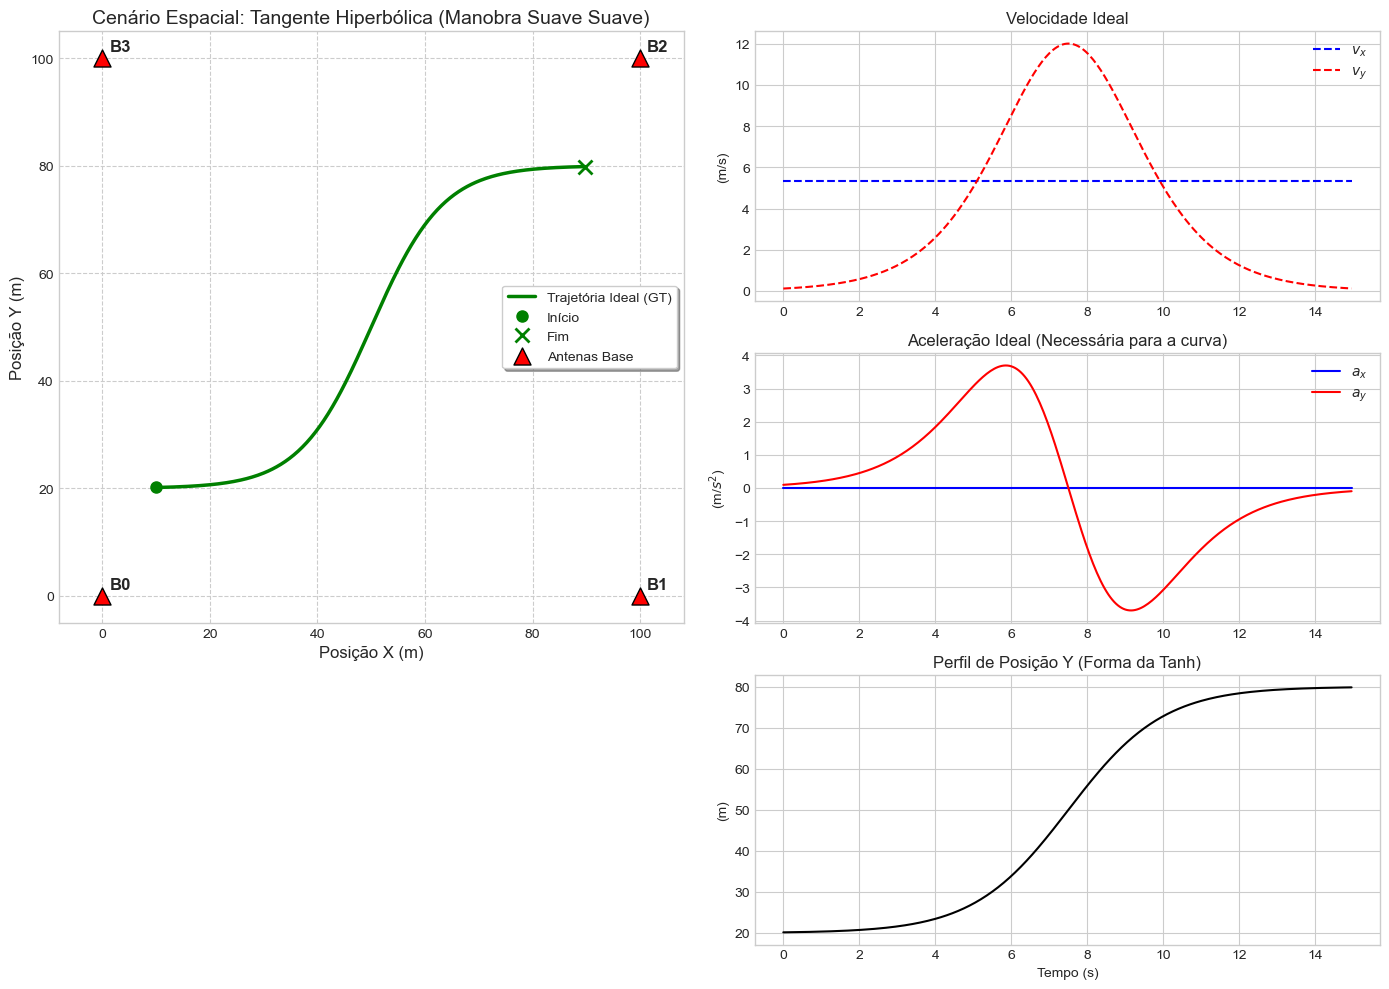

In [586]:
class TrajectoryGenerator:
    def __init__(self, dt: float, bases: np.ndarray):
        """
        Inicializa o gerador de trajetórias.
        dt: Intervalo de tempo entre amostras (s)
        bases: Posição das antenas base (N, 2) [[bx1, by1], ...]
        """
        self.dt = dt
        self.bases = bases
        
        # Plot styling
        plt.style.use('seaborn-v0_8-whitegrid')
        self.fig_size = (10, 8)

    def _init_vectors(self, num_steps: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Inicializa os vetores de tempo e estado PVA (6D)."""
        t = np.linspace(0, (num_steps - 1) * self.dt, num_steps)
        # Estados Verdadeiros (Ground Truth): [px, py, vx, vy, ax, ay]
        states_gt = np.zeros((num_steps, 6))
        return t, states_gt

    def generate_circle(self, radius: float, center: Tuple[float, float], 
                        linear_velocity: float, duration: float) -> Tuple[np.ndarray, np.ndarray]:
        """
        Gera uma trajetória circular com cinemática PVA completa.
        A aceleração gerada é a aceleração centrípeta.
        """
        num_steps = int(duration / self.dt)
        t, states = self._init_vectors(num_steps)
        cx, cy = center
        
        # Velocidade angular (w = v / r)
        omega = linear_velocity / radius
        
        # Ângulo em função do tempo (theta = w * t)
        theta = omega * t
        
        # Posições: [px, py]
        states[:, 0] = cx + radius * np.cos(theta)
        states[:, 1] = cy + radius * np.sin(theta)
        
        # Velocidades (derivada da posição): [vx, vy]
        states[:, 2] = -radius * omega * np.sin(theta)
        states[:, 3] =  radius * omega * np.cos(theta)
        
        # Acelerações (derivada da velocidade): [ax, ay]
        states[:, 4] = -radius * (omega**2) * np.cos(theta)
        states[:, 5] = -radius * (omega**2) * np.sin(theta)
        
        return t, states

    def generate_square(self, side_length: float, bottom_left: Tuple[float, float], 
                        linear_velocity: float) -> Tuple[np.ndarray, np.ndarray]:
        """
        Gera uma trajetória quadrada. 
        Nota: Nas quinas, há descontinuidade de velocidade (aceleração infinita teórica).
        Aqui simulamos velocidade constante nas arestas e mudança brusca na quina.
        """
        time_per_side = side_length / linear_velocity
        steps_per_side = int(time_per_side / self.dt)
        num_steps = steps_per_side * 4
        
        t, states = self._init_vectors(num_steps)
        x0, y0 = bottom_left
        v = linear_velocity
        
        # Areste 1: Direita (v_x = v, v_y = 0)
        idx = slice(0, steps_per_side)
        states[idx, 0] = x0 + v * t[idx]
        states[idx, 1] = y0
        states[idx, 2] = v
        
        # Areste 2: Cima (v_x = 0, v_y = v)
        idx = slice(steps_per_side, 2 * steps_per_side)
        states[idx, 0] = x0 + side_length
        states[idx, 1] = y0 + v * (t[idx] - time_per_side)
        states[idx, 3] = v
        
        # Areste 3: Esquerda (v_x = -v, v_y = 0)
        idx = slice(2 * steps_per_side, 3 * steps_per_side)
        states[idx, 0] = x0 + side_length - v * (t[idx] - 2 * time_per_side)
        states[idx, 1] = y0 + side_length
        states[idx, 2] = -v
        
        # Areste 4: Baixo (v_x = 0, v_y = -v)
        idx = slice(3 * steps_per_side, 4 * steps_per_side)
        states[idx, 0] = x0
        states[idx, 1] = y0 + side_length - v * (t[idx] - 3 * time_per_side)
        states[idx, 3] = -v
        
        # Acelerações são zero nas arestas (modelo PV perfeito).
        # As quinas geram picos de erro no filtro PV.
        return t, states

    def generate_tanh_curve(self, start_pos: Tuple[float, float], end_pos: Tuple[float, float], 
                            amplitude_y: float, smoothness: float, duration: float) -> Tuple[np.ndarray, np.ndarray]:
        """
        Gera uma trajetória suave baseada na tangente hiperbólica (curva em S),
        semelhante a manobras de troca de faixa, com PVA completo.
        """
        num_steps = int(duration / self.dt)
        t, states = self._init_vectors(num_steps)
        x_start, y_start = start_pos
        x_end, y_end = end_pos
        
        # Tempo normalizado (0 a 1) e centralizado (-0.5 a 0.5)
        t_norm = (t / duration) - 0.5
        
        # --- Eixo X (Movimento Linear constante) ---
        dist_x = x_end - x_start
        v_x_const = dist_x / duration
        states[:, 0] = x_start + v_x_const * t # Pos X
        states[:, 2] = v_x_const                # Vel X
        # Acc X = 0
        # --- Eixo Y (Curva Tanh) ---
        y_mid = (y_end + y_start) / 2.0
        
        # Argumento da tanh: controla a inclinação da curva
        # arg = smoothness * t_norm
        
        # Posição Y: y = y_mid + Amp * tanh(smoothness * t_norm)
        tanh_arg = smoothness * t_norm
        states[:, 1] = y_mid + amplitude_y * np.tanh(tanh_arg)
        
        # Derivadas analíticas para Velocidade e Aceleração em Y
        # d/dx tanh(x) = sech^2(x) = 1 - tanh^2(x)
        # Necessário usar regra da cadeia: d(smoothness*t_norm)/dt = smoothness / duration
        sech2_val = 1.0 - (np.tanh(tanh_arg))**2
        factor_dt = smoothness / duration
        
        # Velocidade Y: v_y = Amp * factor_dt * sech^2(arg)
        states[:, 3] = amplitude_y * factor_dt * sech2_val
        
        # Aceleração Y: a_y = d/dt v_y = Amp * factor_dt^2 * d/d(arg)sech^2(arg)
        # d/dx sech^2(x) = -2 * sech^2(x) * tanh(x)
        states[:, 5] = amplitude_y * (factor_dt**2) * (-2.0 * sech2_val * np.tanh(tanh_arg))
        
        return t, states

    def plot_scenario(self, t: np.ndarray, states_gt: np.ndarray, title: str):
        """Planta a trajetória (Ground Truth) e as bases."""
        px = states_gt[:, 0]
        py = states_gt[:, 1]
        vx = states_gt[:, 2]
        vy = states_gt[:, 3]
        ax = states_gt[:, 4]
        ay = states_gt[:, 5]
        
        # Cria figura com subplots (Trajetória + Cinematica)
        fig = plt.figure(figsize=(14, 10))
        gs = fig.add_gridspec(3, 2)
        
        # --- Plot 1: Espacial (X vs Y) ---
        ax_space = fig.add_subplot(gs[0:2, 0])
        
        # Plot Trajetória ideal
        ax_space.plot(px, py, 'g-', linewidth=2.5, label='Trajetória Ideal (GT)')
        
        # Início e Fim
        ax_space.plot(px[0], py[0], 'go', markersize=8, label='Início')
        ax_space.plot(px[-1], py[-1], 'gx', markersize=10, mew=2, label='Fim')
        
        # Plot Bases
        ax_space.scatter(self.bases[:, 0], self.bases[:, 1], 
                         marker='^', s=150, c='red', edgecolor='black', 
                         label='Antenas Base', zorder=5)
        # Numeração das bases
        for i, (bx, by) in enumerate(self.bases):
            ax_space.annotate(f'B{i}', (bx, by), xytext=(5, 5), textcoords='offset points', fontsize=12, fontweight='bold')
            
        ax_space.set_title(f'Cenário Espacial: {title}', fontsize=14)
        ax_space.set_xlabel('Posição X (m)', fontsize=12)
        ax_space.set_ylabel('Posição Y (m)', fontsize=12)
        ax_space.legend(loc='best', frameon=True, shadow=True)
        ax_space.axis('equal') # Mantém proporção 1:1 m
        ax_space.grid(True, which='both', linestyle='--')

        # --- Subplots Cinemática (Tempo) ---
        # Velocidade
        ax_vel = fig.add_subplot(gs[0, 1])
        ax_vel.plot(t, vx, 'b--', label='$v_x$')
        ax_vel.plot(t, vy, 'r--', label='$v_y$')
        ax_vel.set_title('Velocidade Ideal', fontsize=12)
        ax_vel.set_ylabel('(m/s)')
        ax_vel.legend()
        ax_vel.grid(True)
        
        # Aceleração
        ax_acc = fig.add_subplot(gs[1, 1])
        ax_acc.plot(t, ax, 'b-', label='$a_x$')
        ax_acc.plot(t, ay, 'r-', label='$a_y$')
        ax_acc.set_title('Aceleração Ideal (Necessária para a curva)', fontsize=12)
        ax_acc.set_ylabel('(m/$s^2$)')
        ax_acc.legend()
        ax_acc.grid(True)
        
        # Tanh Y específica (para mostrar a forma)
        ax_tanh = fig.add_subplot(gs[2, 1])
        ax_tanh.plot(t, py, 'k-', label='$p_y$ (Forma Tanh)')
        ax_tanh.set_title('Perfil de Posição Y (Forma da Tanh)', fontsize=12)
        ax_tanh.set_xlabel('Tempo (s)')
        ax_tanh.set_ylabel('(m)')
        ax_tanh.grid(True)
        
        fig.tight_layout()
        plt.show()

# ====================================================================
# EXEMPLO DE USO DO GERADOR
# ====================================================================

if __name__ == "__main__":
    # Configurações do cenário (semelhante ao artigo)
    dT_sim = 0.05 # Alta frequência de amostragem para suavidade
    
    # Definição das bases (4 antenas ao redor da área de interesse)
    antenas_base = np.array([
        [0, 0],
        [100, 0],
        [100, 100],
        [0, 100]
    ])
    
    # Instancia o gerador
    gen = TrajectoryGenerator(dT_sim, antenas_base)
    
    print("Gerando Cenários Ground Truth...")

    # --- 1. Cenário Circular ---
    # Raio 30m, centro (50,50), vel linear 10m/s (~36km/h), duração 25s (mais de uma volta)
    t_circ, pva_circ = gen.generate_circle(radius=30, center=(50, 50), linear_velocity=10, duration=25)
    #gen.plot_scenario(t_circ, pva_circ, "Círculo (Aceleração Centrípeta Constante)")

    # --- 2. Cenário Quadrado ---
    # Lado 60m, quina inferior (20,20), vel linear 8m/s
    t_sq, pva_sq = gen.generate_square(side_length=60, bottom_left=(20, 20), linear_velocity=8)
    #gen.plot_scenario(t_sq, pva_sq, "Quadrado (Velocidade Constante, Quinas Bruscas)")

    # --- 3. Cenário Tanh (Troca de Faixa/S-Curve) ---
    # Inicia em (10, 20), termina em X=90. Curva Tanh sobe de Y=20 para Y=80.
    # Duração 15s. Smoothness define a rapidez da transição.
    t_tanh, pva_tanh = gen.generate_tanh_curve(start_pos=(10, 20), end_pos=(90, 80), 
                                               amplitude_y=30, smoothness=6.0, duration=15)
    gen.plot_scenario(t_tanh, pva_tanh, "Tangente Hiperbólica (Manobra Suave Suave)")

## 5.1. Testando Filtro de Kalman com os resultados obtidos.

Dada as funções e as classes já criadas, agora o objetivo é testaro filtro de Kalman para cada uma das figuras.


In [587]:
#===========================================
# Definindo parâmetros globais da simulação
#===========================================
dT_sim = 1e-1

# Posição das estações base (X,Y).
S1 = np.array([0,0]).T
S2 = np.array([600,600]).T
S3 = np.array([0,600]).T
S4 = np.array([600,0]).T

#Variável para iterar sobre elas
bases = np.array([S1,S2,S3,S4])

# Número de antenas para medição
N = bases.shape[0]

print("Tem",N, "Antenas")

antenas_base = bases
gen = TrajectoryGenerator(dT_sim, antenas_base) 

Tem 4 Antenas


## 5.1.1 Kalman Modelo (PV) - Quadrado

In [602]:
#===========================================
# Gerando Trajetórias
#===========================================
t_sq, pva_sq = gen.generate_square(side_length=400, bottom_left=(100, 100), linear_velocity=8)

# Puxando valores reais 
# pva_sq possui 6 colunas, mas para o PV usamos apenas as 4 primeiras (px, py, vx, vy)
px_gt = pva_sq[:, 0]
py_gt = pva_sq[:, 1]
vx_gt = pva_sq[:, 2]
vy_gt = pva_sq[:, 3]

#===========================================
# Configurações do filtro de Kalman
#===========================================
# Estado inicial (assumimos que começa na posição correta, mas velocidade zerada)
x0 = np.array([[px_gt[0]], [py_gt[0]], [vx_gt[0]], [vy_gt[0]]])
P0 = np.eye(4) * 10.0  # Incerteza inicial

# Matriz de Transição de Estado (F) para modelo PV
F = np.array([
    [1, 0, dT_sim, 0],
    [0, 1, 0, dT_sim],
    [0, 0, 1,      0],
    [0, 0, 0,      1]
])

# Covariância do Ruído de Processo (Q)
# Variâncias do ruído contínuo
q1 = 1
q2 = 1
q3 = 1
q4 = 1

# Criando matriz Q discreta:
Q_disc = get_Q_disc_PV([q1, q2, q3, q4], dT_sim)

# Covariância do Ruído de Medição (R)
dp = 2  # seu valor ou objeto
vetor = np.full(N, dp)

# Pegando a matriz R (passando apenas os desvios)
R = create_cov(vetor)

# Instanciando o seu filtro
ekf_pv = EKF_PV(x0, P0, F, Q_disc, R)

# ==============================================
# Histórico para salvar as estimativas
num_steps = len(t_sq)
estados_estimados = np.zeros((num_steps, 4))


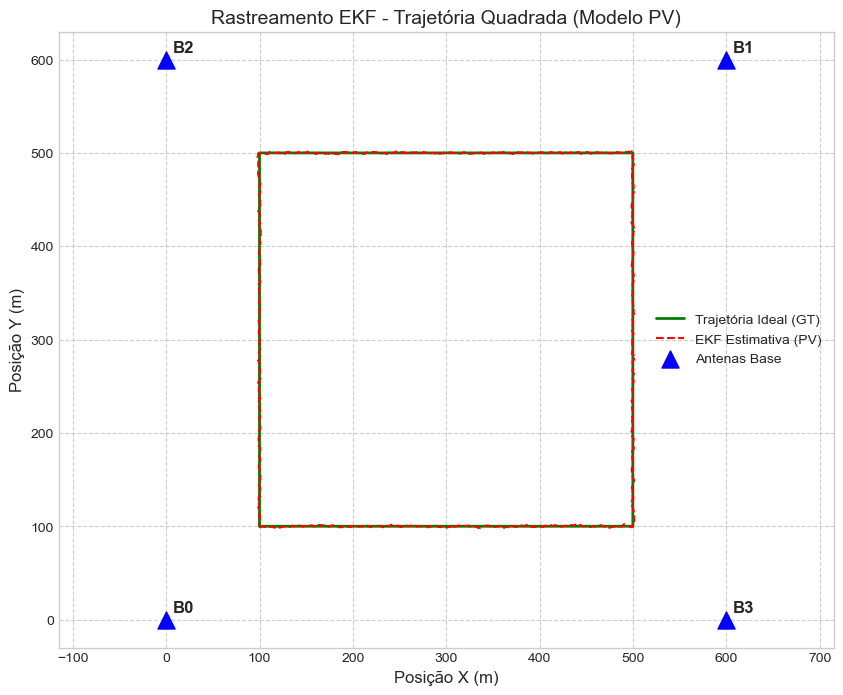

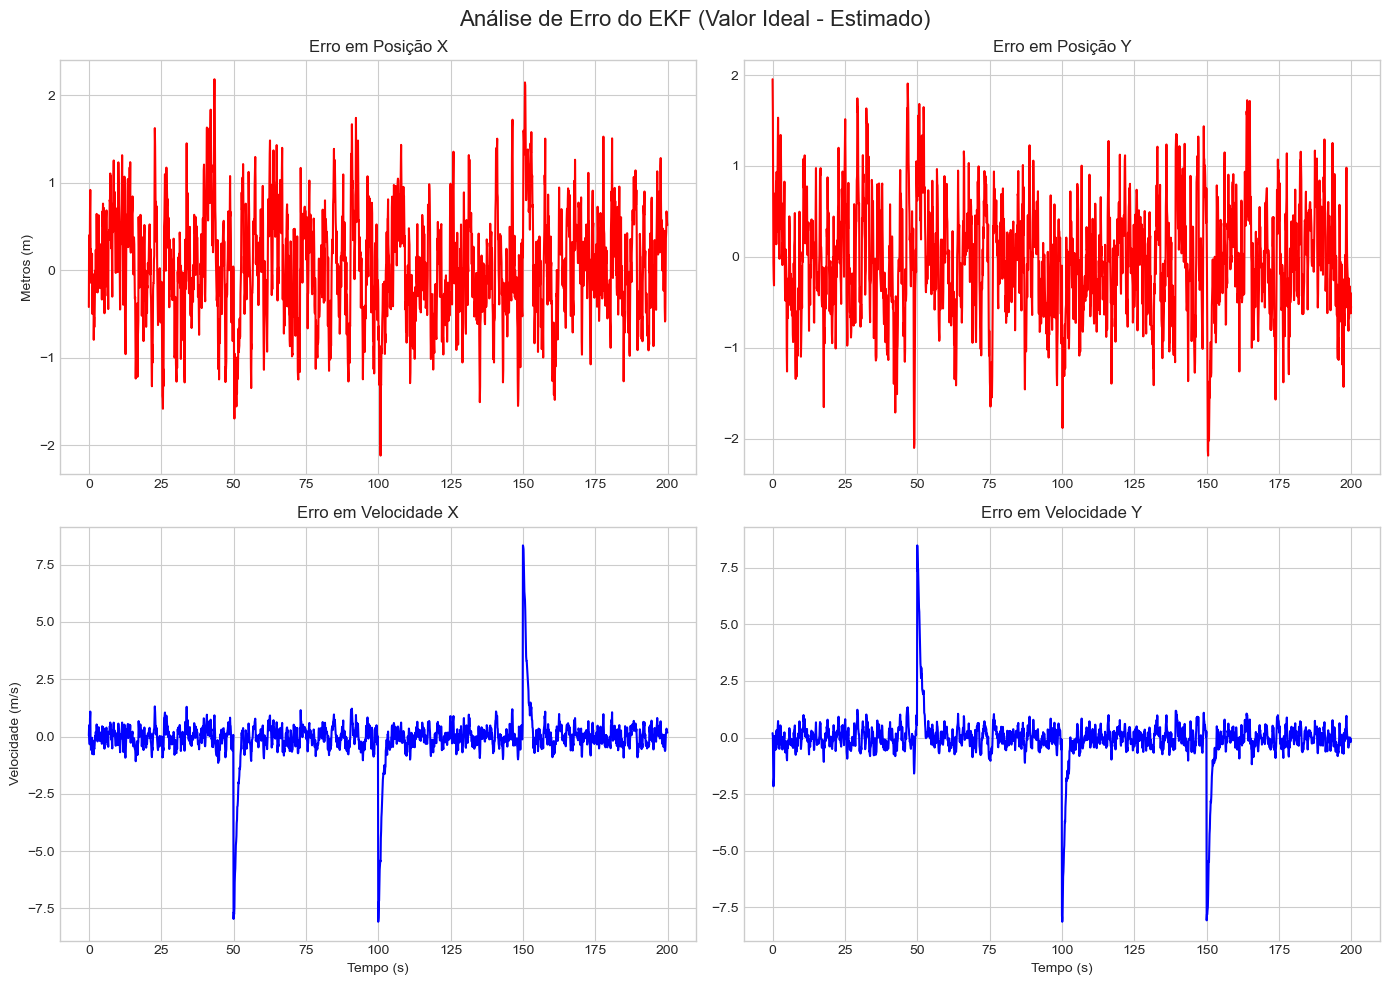

Erro médio quadrático:  0.6971542649254938


In [603]:
# ====================================================================
# 3. LOOP DE SIMULAÇÃO E RASTREAMENTO
# ====================================================================
for k in range(num_steps):
    # a) Simulação da medição real (Extraímos a distância ideal e adicionamos ruído)
    # Criamos um vetor coluna com o estado real no instante k
    x_real_k = np.array([[px_gt[k]], [py_gt[k]], [vx_gt[k]], [vy_gt[k]]])
    pos = np.array([[px_gt[k]], [py_gt[k]]])
    
    # Usamos a sua função matemática para calcular as distâncias exatas h(x)
    hx_real, _ = calc_h_and_H_PV(x_real_k, antenas_base)
    
    # Injetamos ruído para simular o sensor Z real
    # Recuperando o vetor de erros aleatórios (4x1)
    v_t = get_noise_vec(R)
    
    # Medição final ruidosa (transpondo pos para broadcasting)
    z_medido = h_obs(pos.T, bases) + v_t
    
    # b) Execução do Filtro de Kalman
    ekf_pv.predict()
    ekf_pv.update(z_medido, antenas_base)
    
    # c) Salvando o estado estimado (achatando de (4,1) para (4,))
    estados_estimados[k, :] = ekf_pv.x.flatten()

# Extraindo as estimativas para variáveis isoladas
px_est = estados_estimados[:, 0]
py_est = estados_estimados[:, 1]
vx_est = estados_estimados[:, 2]
vy_est = estados_estimados[:, 3]

# ====================================================================
# 4. PLOTAGEM E CÁLCULO DE ERROS
# ====================================================================
# Cálculo dos erros (Ground Truth - Estimado)
erro_px = px_gt - px_est
erro_py = py_gt - py_est
erro_vx = vx_gt - vx_est
erro_vy = vy_gt - vy_est

# Plot 1: Trajetória 2D
plt.figure(figsize=(10, 8))
plt.plot(px_gt, py_gt, label='Trajetória Ideal (GT)', color='green', linewidth=2)
plt.plot(px_est, py_est, label='EKF Estimativa (PV)', color='red', linestyle='dashed')
plt.scatter(antenas_base[:, 0], antenas_base[:, 1], c='blue', marker='^', s=150, label='Antenas Base')
for i, (bx, by) in enumerate(antenas_base):
    plt.annotate(f'B{i}', (bx, by), xytext=(5, 5), textcoords='offset points', fontsize=12, fontweight='bold')

plt.title('Rastreamento EKF - Trajetória Quadrada (Modelo PV)', fontsize=14)
plt.xlabel('Posição X (m)', fontsize=12)
plt.ylabel('Posição Y (m)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--')
plt.axis('equal')
plt.show()

# Plot 2: Análise de Erros nos Estados
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análise de Erro do EKF (Valor Ideal - Estimado)', fontsize=16)

# Posição X
axs[0, 0].plot(t_sq, erro_px, color='red')
axs[0, 0].set_title('Erro em Posição X', fontsize=12)
axs[0, 0].set_ylabel('Metros (m)')
axs[0, 0].grid(True)

# Posição Y
axs[0, 1].plot(t_sq, erro_py, color='red')
axs[0, 1].set_title('Erro em Posição Y', fontsize=12)
axs[0, 1].grid(True)

# Velocidade X
axs[1, 0].plot(t_sq, erro_vx, color='blue')
axs[1, 0].set_title('Erro em Velocidade X', fontsize=12)
axs[1, 0].set_xlabel('Tempo (s)')
axs[1, 0].set_ylabel('Velocidade (m/s)')
axs[1, 0].grid(True)

# Velocidade Y
axs[1, 1].plot(t_sq, erro_vy, color='blue')
axs[1, 1].set_title('Erro em Velocidade Y', fontsize=12)
axs[1, 1].set_xlabel('Tempo (s)')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()


# RMS
erro = erro_px + erro_py
erro2 = np.square(erro)
rms = np.mean(erro2)

print("Erro médio quadrático: ", rms)

## 5.1.2. Kalman Modelo (PV) - Círculo

In [590]:
#===========================================
# Gerando Trajetórias
#===========================================
r = 200
cx,cy = 300, 300
lv = 10
t = 2*4*r/lv
t_circ, pv_circ = gen.generate_circle(radius=r, center=(cx, cy), linear_velocity=lv, duration=t)

# Puxando valores reais 
# pva_sq possui 6 colunas, mas para o PV usamos apenas as 4 primeiras (px, py, vx, vy)
px_gt = pv_circ[:, 0]
py_gt = pv_circ[:, 1]
vx_gt = pv_circ[:, 2]
vy_gt = pv_circ[:, 3]

#===========================================
# Configurações do filtro de Kalman
#===========================================
# Estado inicial (assumimos que começa na posição correta, mas velocidade zerada)
x0 = np.array([[px_gt[0]], [py_gt[0]], [0.0], [0.0]])  #Estado Inicial!
P0 = np.eye(4) * 10.0  # Incerteza inicial

# Matriz de Transição de Estado (F) para modelo PV
F = np.array([
    [1, 0, dT_sim, 0],
    [0, 1, 0, dT_sim],
    [0, 0, 1,      0],
    [0, 0, 0,      1]
])

# Covariância do Ruído de Processo (Q)
# Variâncias do ruído contínuo
q1 = 2
q2 = 2
q3 = 2
q4 = 2

# Criando matriz Q discreta:
Q_disc = get_Q_disc_PV([q1, q2, q3, q4], dT_sim)

# Covariância do Ruído de Medição (R)
dp = 2  # seu valor ou objeto
vetor = np.full(N, dp)

# Pegando a matriz R (passando apenas os desvios)
R = create_cov(vetor)

# Instanciando o seu filtro
ekf_pv = EKF_PV(x0, P0, F, Q_disc, R)

#---------------------------------------------
# Histórico para salvar as estimativas
num_steps = len(t_circ)
estados_estimados = np.zeros((num_steps, 4))


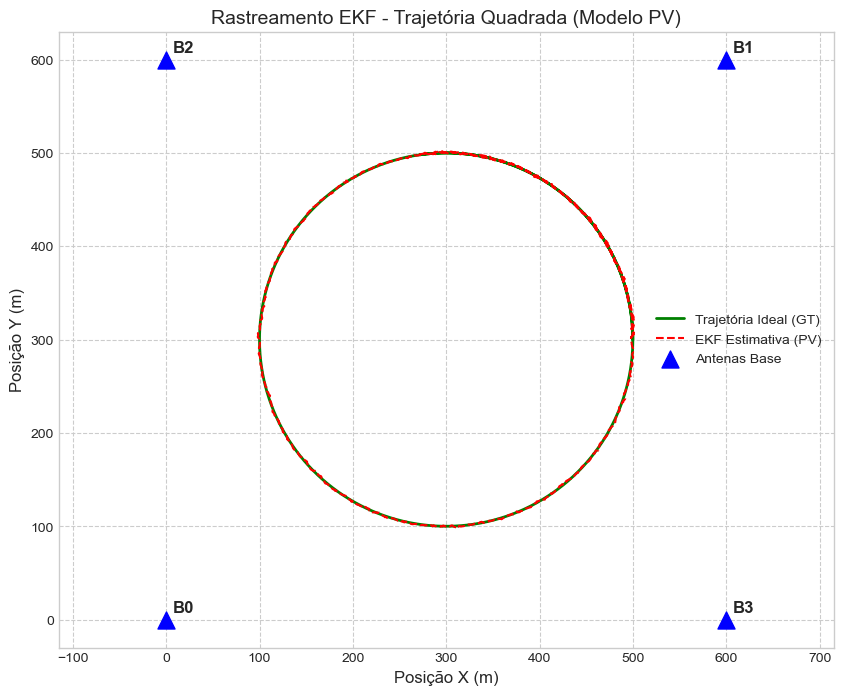

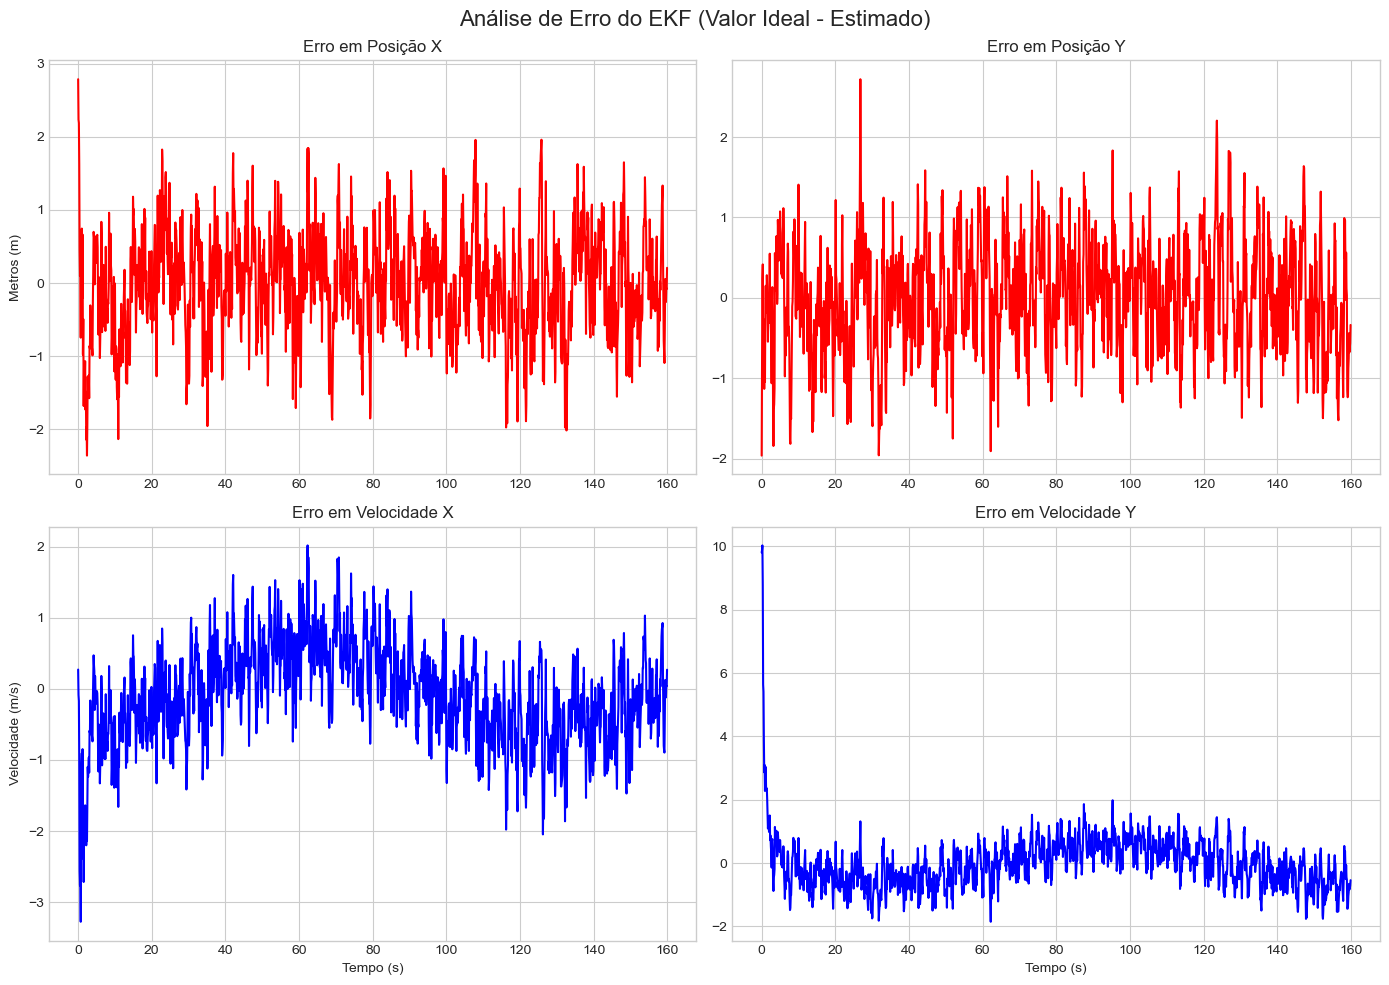

Erro médio quadrático:  0.948231087429785


In [591]:
# ====================================================================
# 3. LOOP DE SIMULAÇÃO E RASTREAMENTO
# ====================================================================
for k in range(num_steps):
    # a) Simulação da medição real (Extraímos a distância ideal e adicionamos ruído)
    # Criamos um vetor coluna com o estado real no instante k
    x_real_k = np.array([[px_gt[k]], [py_gt[k]], [vx_gt[k]], [vy_gt[k]]])
    pos = np.array([[px_gt[k]], [py_gt[k]]])
    
    # Usamos a sua função matemática para calcular as distâncias exatas h(x)
    hx_real, _ = calc_h_and_H_PV(x_real_k, antenas_base)
    
    # Injetamos ruído para simular o sensor Z real
    # Recuperando o vetor de erros aleatórios (4x1)
    v_t = get_noise_vec(R)
    
    # Medição final ruidosa (transpondo pos para broadcasting)
    z_medido = h_obs(pos.T, bases) + v_t
    
    # b) Execução do Filtro de Kalman
    ekf_pv.predict()
    ekf_pv.update(z_medido, antenas_base)
    
    # c) Salvando o estado estimado (achatando de (4,1) para (4,))
    estados_estimados[k, :] = ekf_pv.x.flatten()

# Extraindo as estimativas para variáveis isoladas
px_est = estados_estimados[:, 0]
py_est = estados_estimados[:, 1]
vx_est = estados_estimados[:, 2]
vy_est = estados_estimados[:, 3]

# ====================================================================
# 4. PLOTAGEM E CÁLCULO DE ERROS
# ====================================================================
# Cálculo dos erros (Ground Truth - Estimado)
erro_px = px_gt - px_est
erro_py = py_gt - py_est
erro_vx = vx_gt - vx_est
erro_vy = vy_gt - vy_est

# Plot 1: Trajetória 2D
plt.figure(figsize=(10, 8))
plt.plot(px_gt, py_gt, label='Trajetória Ideal (GT)', color='green', linewidth=2)
plt.plot(px_est, py_est, label='EKF Estimativa (PV)', color='red', linestyle='dashed')
plt.scatter(antenas_base[:, 0], antenas_base[:, 1], c='blue', marker='^', s=150, label='Antenas Base')
for i, (bx, by) in enumerate(antenas_base):
    plt.annotate(f'B{i}', (bx, by), xytext=(5, 5), textcoords='offset points', fontsize=12, fontweight='bold')

plt.title('Rastreamento EKF - Trajetória Quadrada (Modelo PV)', fontsize=14)
plt.xlabel('Posição X (m)', fontsize=12)
plt.ylabel('Posição Y (m)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--')
plt.axis('equal')
plt.show()

# Plot 2: Análise de Erros nos Estados
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análise de Erro do EKF (Valor Ideal - Estimado)', fontsize=16)

# Posição X
axs[0, 0].plot(t_circ, erro_px, color='red')
axs[0, 0].set_title('Erro em Posição X', fontsize=12)
axs[0, 0].set_ylabel('Metros (m)')
axs[0, 0].grid(True)

# Posição Y
axs[0, 1].plot(t_circ, erro_py, color='red')
axs[0, 1].set_title('Erro em Posição Y', fontsize=12)
axs[0, 1].grid(True)

# Velocidade X
axs[1, 0].plot(t_circ, erro_vx, color='blue')
axs[1, 0].set_title('Erro em Velocidade X', fontsize=12)
axs[1, 0].set_xlabel('Tempo (s)')
axs[1, 0].set_ylabel('Velocidade (m/s)')
axs[1, 0].grid(True)

# Velocidade Y
axs[1, 1].plot(t_circ, erro_vy, color='blue')
axs[1, 1].set_title('Erro em Velocidade Y', fontsize=12)
axs[1, 1].set_xlabel('Tempo (s)')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()


# RMS
erro = erro_px + erro_py
erro2 = np.square(erro)
rms = np.mean(erro2)

print("Erro médio quadrático: ", rms)

## 5.1.3. Kalman Modelo (PV) - Curva

In [592]:
#===========================================
# Gerando Trajetórias
#===========================================
t_tanh, pva_tanh = gen.generate_tanh_curve(start_pos=(100, 100), end_pos=(500, 500), 
                                               amplitude_y=200, smoothness=6.0, duration=100)
# Puxando valores reais 
# pva_sq possui 6 colunas, mas para o PV usamos apenas as 4 primeiras (px, py, vx, vy)
px_gt = pva_tanh[:, 0]
py_gt = pva_tanh[:, 1]
vx_gt = pva_tanh[:, 2]
vy_gt = pva_tanh[:, 3]

#===========================================
# Configurações do filtro de Kalman
#===========================================
# Estado inicial (assumimos que começa na posição correta, mas velocidade zerada)
x0 = np.array([[px_gt[0]], [py_gt[0]], [0.0], [0.0]])  #Estado Inicial!
P0 = np.eye(4) * 10.0  # Incerteza inicial

# Matriz de Transição de Estado (F) para modelo PV
F = np.array([
    [1, 0, dT_sim, 0],
    [0, 1, 0, dT_sim],
    [0, 0, 1,      0],
    [0, 0, 0,      1]
])

# Covariância do Ruído de Processo (Q)
# Variâncias do ruído contínuo
q1 = 2
q2 = 2
q3 = 2
q4 = 2

# Criando matriz Q discreta:
Q_disc = get_Q_disc_PV([q1, q2, q3, q4], dT_sim)

# Covariância do Ruído de Medição (R)
dp = 2  # seu valor ou objeto
vetor = np.full(N, dp)

# Pegando a matriz R (passando apenas os desvios)
R = create_cov(vetor)

# Instanciando o seu filtro
ekf_pv = EKF_PV(x0, P0, F, Q_disc, R)


# Histórico para salvar as estimativas
num_steps = len(t_tanh)
estados_estimados = np.zeros((num_steps, 4))


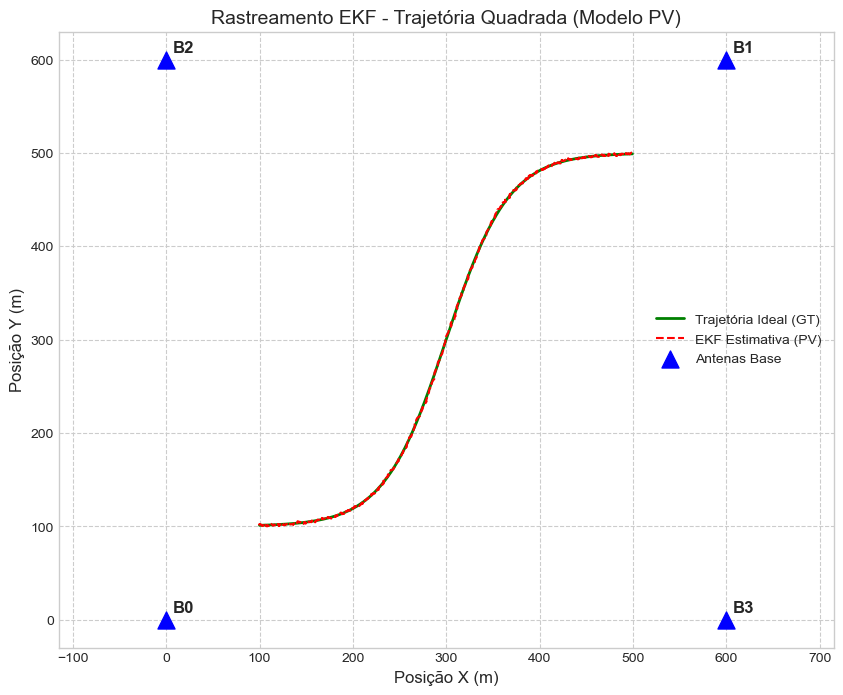

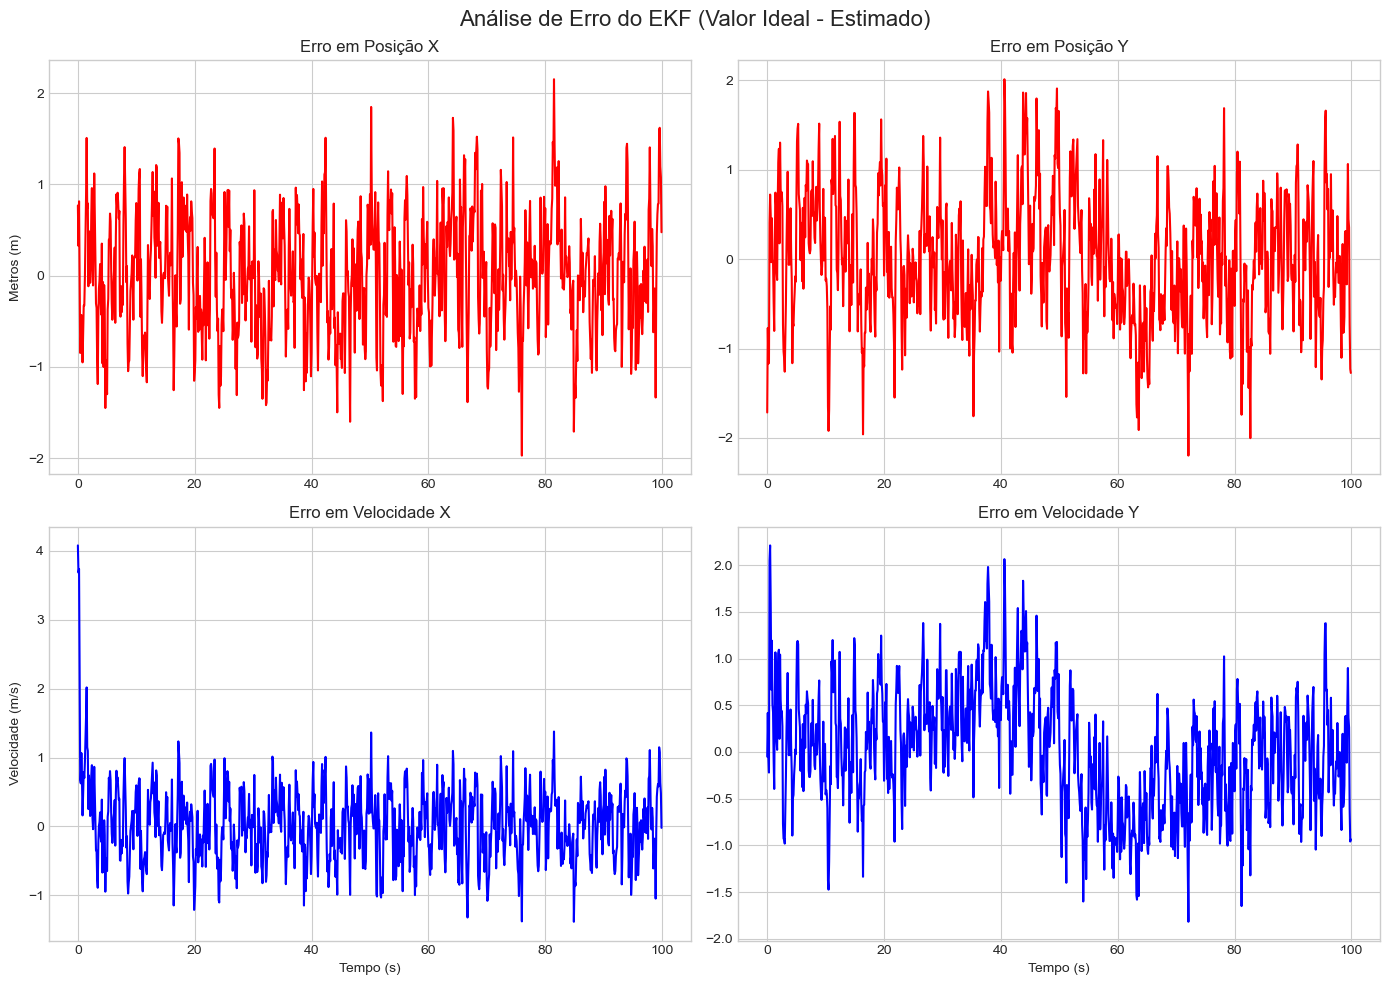

Erro médio quadrático:  0.75555935477866


In [593]:
# ====================================================================
# 3. LOOP DE SIMULAÇÃO E RASTREAMENTO
# ====================================================================
for k in range(num_steps):
    # a) Simulação da medição real (Extraímos a distância ideal e adicionamos ruído)
    # Criamos um vetor coluna com o estado real no instante k
    x_real_k = np.array([[px_gt[k]], [py_gt[k]], [vx_gt[k]], [vy_gt[k]]])
    pos = np.array([[px_gt[k]], [py_gt[k]]])
    
    # Usamos a sua função matemática para calcular as distâncias exatas h(x)
    hx_real, _ = calc_h_and_H_PV(x_real_k, antenas_base)
    
    # Injetamos ruído para simular o sensor Z real
    # Recuperando o vetor de erros aleatórios (4x1)
    v_t = get_noise_vec(R)
    
    # Medição final ruidosa (transpondo pos para broadcasting)
    z_medido = h_obs(pos.T, bases) + v_t
    
    # b) Execução do Filtro de Kalman
    ekf_pv.predict()
    ekf_pv.update(z_medido, antenas_base)
    
    # c) Salvando o estado estimado (achatando de (4,1) para (4,))
    estados_estimados[k, :] = ekf_pv.x.flatten()

# Extraindo as estimativas para variáveis isoladas
px_est = estados_estimados[:, 0]
py_est = estados_estimados[:, 1]
vx_est = estados_estimados[:, 2]
vy_est = estados_estimados[:, 3]

# ====================================================================
# 4. PLOTAGEM E CÁLCULO DE ERROS
# ====================================================================
# Cálculo dos erros (Ground Truth - Estimado)
erro_px = px_gt - px_est
erro_py = py_gt - py_est
erro_vx = vx_gt - vx_est
erro_vy = vy_gt - vy_est

# Plot 1: Trajetória 2D
plt.figure(figsize=(10, 8))
plt.plot(px_gt, py_gt, label='Trajetória Ideal (GT)', color='green', linewidth=2)
plt.plot(px_est, py_est, label='EKF Estimativa (PV)', color='red', linestyle='dashed')
plt.scatter(antenas_base[:, 0], antenas_base[:, 1], c='blue', marker='^', s=150, label='Antenas Base')
for i, (bx, by) in enumerate(antenas_base):
    plt.annotate(f'B{i}', (bx, by), xytext=(5, 5), textcoords='offset points', fontsize=12, fontweight='bold')

plt.title('Rastreamento EKF - Trajetória Quadrada (Modelo PV)', fontsize=14)
plt.xlabel('Posição X (m)', fontsize=12)
plt.ylabel('Posição Y (m)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--')
plt.axis('equal')
plt.show()

# Plot 2: Análise de Erros nos Estados
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análise de Erro do EKF (Valor Ideal - Estimado)', fontsize=16)

# Posição X
axs[0, 0].plot(t_tanh, erro_px, color='red')
axs[0, 0].set_title('Erro em Posição X', fontsize=12)
axs[0, 0].set_ylabel('Metros (m)')
axs[0, 0].grid(True)

# Posição Y
axs[0, 1].plot(t_tanh, erro_py, color='red')
axs[0, 1].set_title('Erro em Posição Y', fontsize=12)
axs[0, 1].grid(True)

# Velocidade X
axs[1, 0].plot(t_tanh, erro_vx, color='blue')
axs[1, 0].set_title('Erro em Velocidade X', fontsize=12)
axs[1, 0].set_xlabel('Tempo (s)')
axs[1, 0].set_ylabel('Velocidade (m/s)')
axs[1, 0].grid(True)

# Velocidade Y
axs[1, 1].plot(t_tanh, erro_vy, color='blue')
axs[1, 1].set_title('Erro em Velocidade Y', fontsize=12)
axs[1, 1].set_xlabel('Tempo (s)')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()


# RMS
erro = erro_px + erro_py
erro2 = np.square(erro)
rms = np.mean(erro2)

print("Erro médio quadrático: ", rms)

Para os Modelos PVA:

In [594]:
#===========================================
# Definindo parâmetros globais da simulação
#===========================================
dT_sim = 1e-1
antenas_base = bases
gen = TrajectoryGenerator(dT_sim, antenas_base) 

## 5.1.4 Kalman Modelo (PVA) - Quadrado

In [595]:
#===========================================
# Gerando Trajetórias
#===========================================
t_sq, pva_sq = gen.generate_square(side_length=400, bottom_left=(100, 100), linear_velocity=8)

# Puxando valores reais 
# pva_sq possui 6 colunas
px_gt = pva_sq[:, 0]
py_gt = pva_sq[:, 1]
vx_gt = pva_sq[:, 2]
vy_gt = pva_sq[:, 3]
ax_gt = pva_sq[:, 4]
ay_gt = pva_sq[:, 5]

#===========================================
# Configurações do filtro de Kalman
#===========================================
# Estado inicial (assumimos que começa na posição correta, mas velocidade zerada)
x0 = np.array([[px_gt[0]], [py_gt[0]], [vx_gt[0]], [vy_gt[0]],[ax_gt[0]], [ay_gt[0]]])
P0 = np.eye(6) * 10.0  # Incerteza inicial

# Definindo a Matriz Contínua A 
A = np.array([[0, 0, 1, 0, 0, 0],
              [0, 0, 0, 1, 0, 0],
              [0, 0, 0, 0, 1, 0],
              [0, 0, 0, 0, 0, 1],
              [0, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 0]
             ])

# Gerando a Matriz de Transição F (e^{A*dT})
F = expm(A * dT_sim)

# Variâncias do ruído contínuo
q1 = 2
q2 = 2
q3 = 2
q4 = 2
q5 = 2
q6 = 2 

# Criando matriz Q discreta:
Q_disc = get_Q_disc_PVA([q1, q2, q3, q4, q5, q6], dT_sim)


# Covariância do Ruído de Medição (R)
dp = 1  # seu valor ou objeto
vetor = np.full(N, dp)

# Pegando a matriz R (passando apenas os desvios)
R = create_cov(vetor)

# Instanciando o seu filtro
ekf_pva = EKF_PVA(x0, P0, F, Q_disc, R)

# ==============================================
# Histórico para salvar as estimativas
num_steps = len(t_sq)
estados_estimados = np.zeros((num_steps, 6))


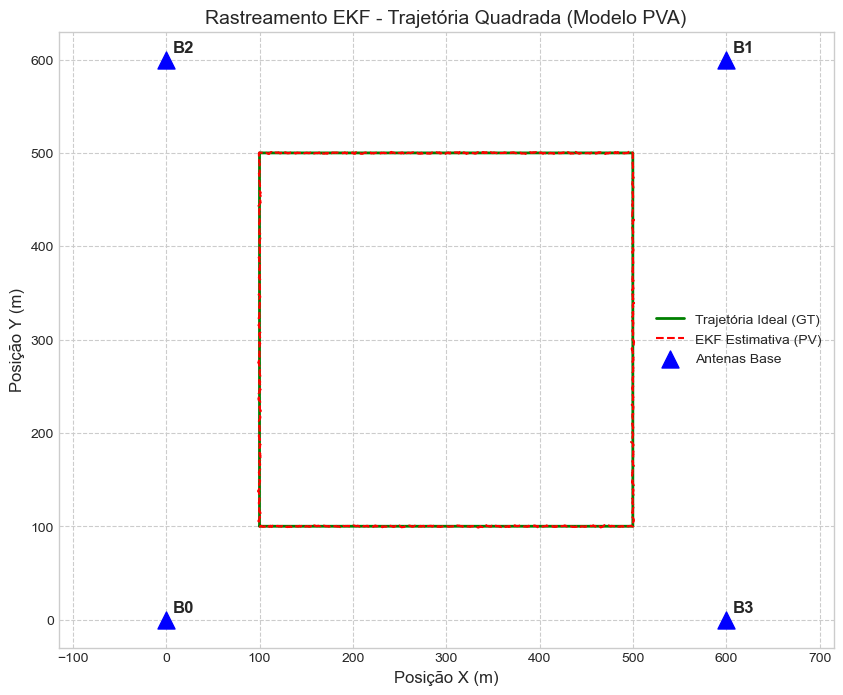

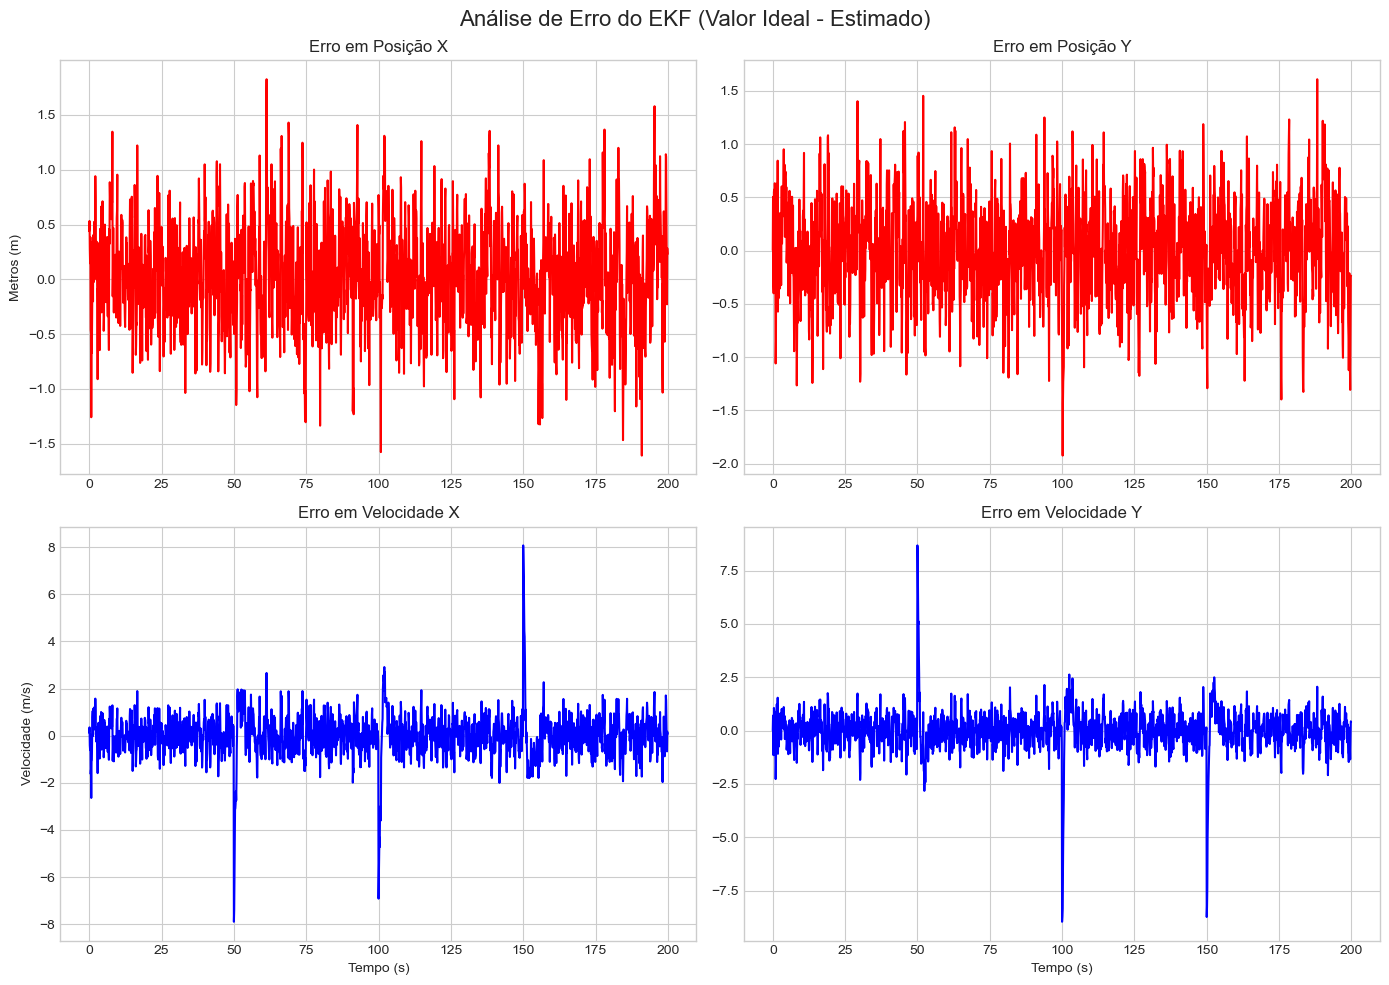

Erro médio quadrático:  0.4077129467979483


In [596]:
# ====================================================================
# 3. LOOP DE SIMULAÇÃO E RASTREAMENTO
# ====================================================================
for k in range(num_steps):
    # a) Simulação da medição real (Extraímos a distância ideal e adicionamos ruído)
    # Criamos um vetor coluna com o estado real no instante k
    x_real_k = np.array([[px_gt[k]], [py_gt[k]], [vx_gt[k]], [vy_gt[k]],[ax_gt[k]], [ay_gt[k]]])
    pos = np.array([[px_gt[k]], [py_gt[k]]])
    
    # Usamos a sua função matemática para calcular as distâncias exatas h(x)
    hx_real, _ = calc_h_and_H_PVA(x_real_k, antenas_base)
    
    # Injetamos ruído para simular o sensor Z real
    # Recuperando o vetor de erros aleatórios (4x1)
    v_t = get_noise_vec(R)
    
    # Medição final ruidosa (transpondo pos para broadcasting)
    z_medido = h_obs(pos.T, bases) + v_t

    # b) Execução do Filtro de Kalman
    ekf_pva.predict()
    ekf_pva.update(z_medido, antenas_base)
    
    # c) Salvando o estado estimado (achatando de (4,1) para (4,))
    estados_estimados[k, :] = ekf_pva.x.flatten()



# Extraindo as estimativas para variáveis isoladas
px_est = estados_estimados[:, 0]
py_est = estados_estimados[:, 1]
vx_est = estados_estimados[:, 2]
vy_est = estados_estimados[:, 3]

# ====================================================================
# 4. PLOTAGEM E CÁLCULO DE ERROS
# ====================================================================
# Cálculo dos erros (Ground Truth - Estimado)
erro_px = px_gt - px_est
erro_py = py_gt - py_est
erro_vx = vx_gt - vx_est
erro_vy = vy_gt - vy_est

# Plot 1: Trajetória 2D
plt.figure(figsize=(10, 8))
plt.plot(px_gt, py_gt, label='Trajetória Ideal (GT)', color='green', linewidth=2)
plt.plot(px_est, py_est, label='EKF Estimativa (PV)', color='red', linestyle='dashed')
plt.scatter(antenas_base[:, 0], antenas_base[:, 1], c='blue', marker='^', s=150, label='Antenas Base')
for i, (bx, by) in enumerate(antenas_base):
    plt.annotate(f'B{i}', (bx, by), xytext=(5, 5), textcoords='offset points', fontsize=12, fontweight='bold')

plt.title('Rastreamento EKF - Trajetória Quadrada (Modelo PVA)', fontsize=14)
plt.xlabel('Posição X (m)', fontsize=12)
plt.ylabel('Posição Y (m)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--')
plt.axis('equal')
plt.show()

# Plot 2: Análise de Erros nos Estados
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análise de Erro do EKF (Valor Ideal - Estimado)', fontsize=16)

# Posição X
axs[0, 0].plot(t_sq, erro_px, color='red')
axs[0, 0].set_title('Erro em Posição X', fontsize=12)
axs[0, 0].set_ylabel('Metros (m)')
axs[0, 0].grid(True)

# Posição Y
axs[0, 1].plot(t_sq, erro_py, color='red')
axs[0, 1].set_title('Erro em Posição Y', fontsize=12)
axs[0, 1].grid(True)

# Velocidade X
axs[1, 0].plot(t_sq, erro_vx, color='blue')
axs[1, 0].set_title('Erro em Velocidade X', fontsize=12)
axs[1, 0].set_xlabel('Tempo (s)')
axs[1, 0].set_ylabel('Velocidade (m/s)')
axs[1, 0].grid(True)

# Velocidade Y
axs[1, 1].plot(t_sq, erro_vy, color='blue')
axs[1, 1].set_title('Erro em Velocidade Y', fontsize=12)
axs[1, 1].set_xlabel('Tempo (s)')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()


# RMS
erro = erro_px + erro_py
erro2 = np.square(erro)
rms = np.mean(erro2)

print("Erro médio quadrático: ", rms)

## 5.1.5. Kalman Modelo (PVA) - Círculo

In [597]:
#===========================================
# Gerando Trajetórias
#===========================================
r = 200
cx,cy = 300, 300
lv = 10
t = 2*4*r/lv
t_sq, pva_sq = gen.generate_circle(radius=r, center=(cx, cy), linear_velocity=lv, duration=t)

# Puxando valores reais 
# pva_sq possui 6 colunas
px_gt = pva_sq[:, 0]
py_gt = pva_sq[:, 1]
vx_gt = pva_sq[:, 2]
vy_gt = pva_sq[:, 3]
ax_gt = pva_sq[:, 4]
ay_gt = pva_sq[:, 5]

#===========================================
# Configurações do filtro de Kalman
#===========================================
# Estado inicial (assumimos que começa na posição correta, mas velocidade zerada)
x0 = np.array([[px_gt[0]], [py_gt[0]], [0.0], [0.0],[0.0], [0.0]])
P0 = np.eye(6) * 10.0  # Incerteza inicial

# Definindo a Matriz Contínua A 
A = np.array([[0, 0, 1, 0, 0, 0],
              [0, 0, 0, 1, 0, 0],
              [0, 0, 0, 0, 1, 0],
              [0, 0, 0, 0, 0, 1],
              [0, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 0]
             ])

# Gerando a Matriz de Transição F (e^{A*dT})
F = expm(A * dT_sim)

# Variâncias do ruído contínuo
q1 = 4
q2 = 4
q3 = 4
q4 = 4
q5 = 4
q6 = 4 

# Criando matriz Q discreta:
Q_disc = get_Q_disc_PVA([q1, q2, q3, q4, q5, q6], dT_sim)


# Covariância do Ruído de Medição (R)
dp = 1  # seu valor ou objeto
vetor = np.full(N, dp)

# Pegando a matriz R (passando apenas os desvios)
R = create_cov(vetor)

# Instanciando o seu filtro
ekf_pva = EKF_PVA(x0, P0, F, Q_disc, R)

# ==============================================
# Histórico para salvar as estimativas
num_steps = len(t_sq)
estados_estimados = np.zeros((num_steps, 6))


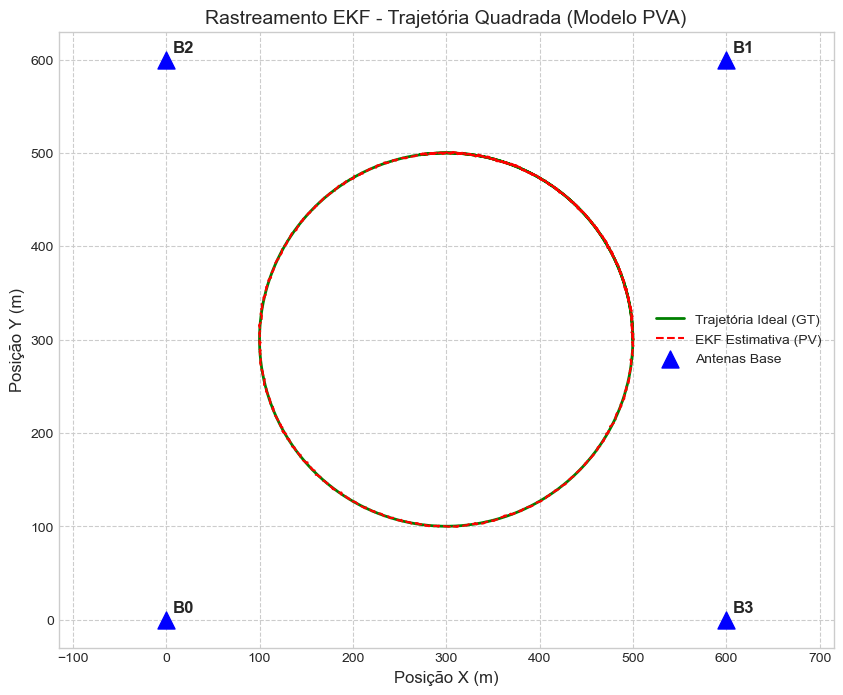

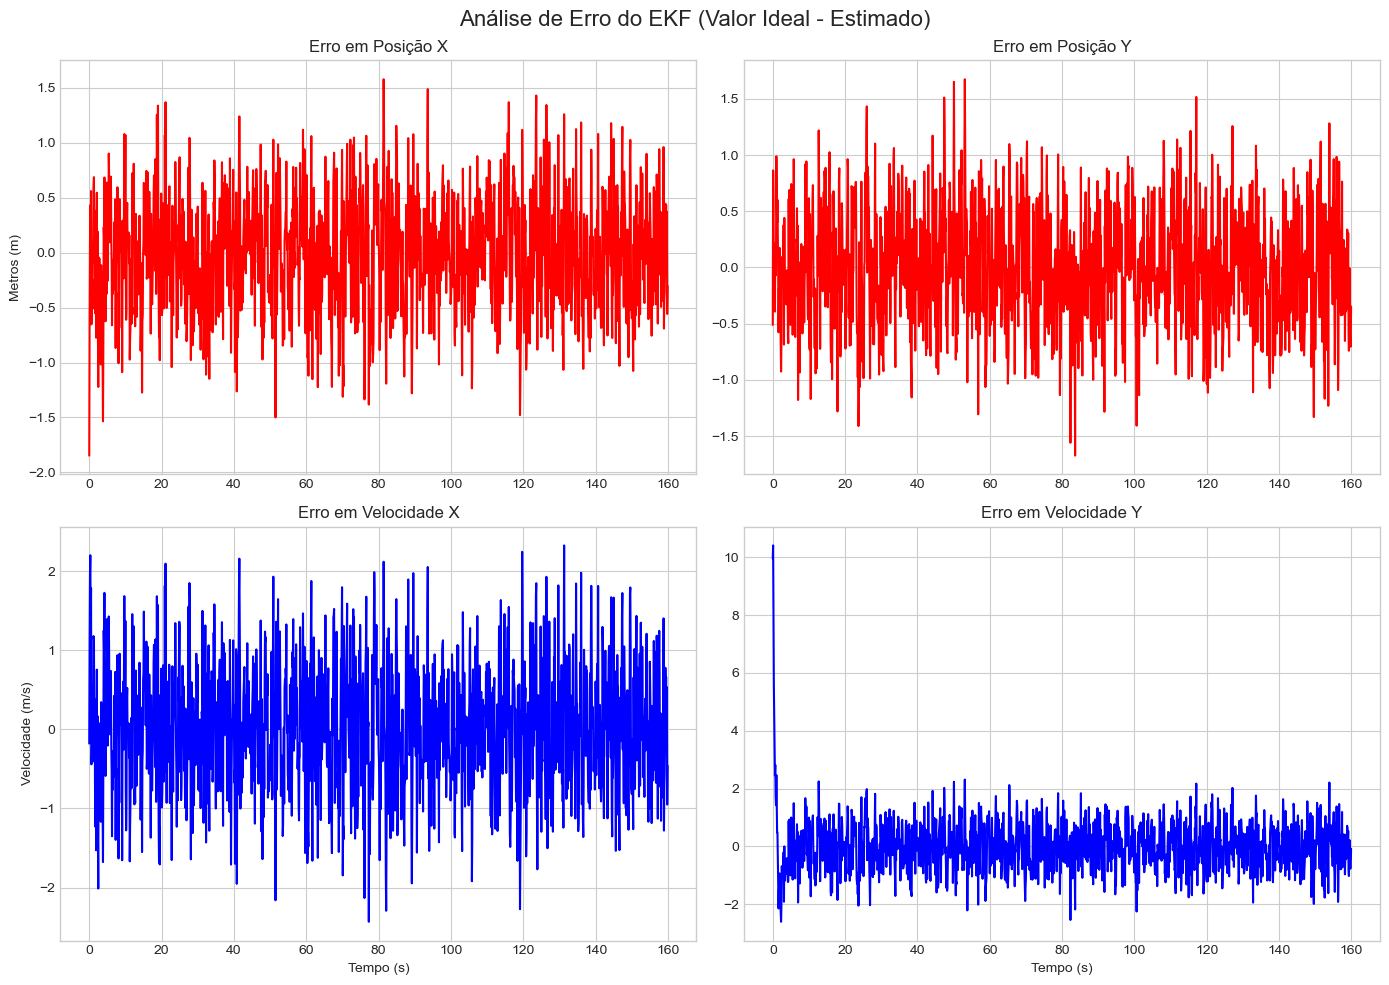

Erro médio quadrático:  0.5013278412860599


In [598]:
# ====================================================================
# 3. LOOP DE SIMULAÇÃO E RASTREAMENTO
# ====================================================================
for k in range(num_steps):
    # a) Simulação da medição real (Extraímos a distância ideal e adicionamos ruído)
    # Criamos um vetor coluna com o estado real no instante k
    x_real_k = np.array([[px_gt[k]], [py_gt[k]], [vx_gt[k]], [vy_gt[k]],[ax_gt[k]], [ay_gt[k]]])
    pos = np.array([[px_gt[k]], [py_gt[k]]])
    
    # Usamos a sua função matemática para calcular as distâncias exatas h(x)
    hx_real, _ = calc_h_and_H_PVA(x_real_k, antenas_base)
    
    # Injetamos ruído para simular o sensor Z real
    # Recuperando o vetor de erros aleatórios (4x1)
    v_t = get_noise_vec(R)
    
    # Medição final ruidosa (transpondo pos para broadcasting)
    z_medido = h_obs(pos.T, bases) + v_t

    # b) Execução do Filtro de Kalman
    ekf_pva.predict()
    ekf_pva.update(z_medido, antenas_base)
    
    # c) Salvando o estado estimado (achatando de (4,1) para (4,))
    estados_estimados[k, :] = ekf_pva.x.flatten()



# Extraindo as estimativas para variáveis isoladas
px_est = estados_estimados[:, 0]
py_est = estados_estimados[:, 1]
vx_est = estados_estimados[:, 2]
vy_est = estados_estimados[:, 3]

# ====================================================================
# 4. PLOTAGEM E CÁLCULO DE ERROS
# ====================================================================
# Cálculo dos erros (Ground Truth - Estimado)
erro_px = px_gt - px_est
erro_py = py_gt - py_est
erro_vx = vx_gt - vx_est
erro_vy = vy_gt - vy_est

# Plot 1: Trajetória 2D
plt.figure(figsize=(10, 8))
plt.plot(px_gt, py_gt, label='Trajetória Ideal (GT)', color='green', linewidth=2)
plt.plot(px_est, py_est, label='EKF Estimativa (PV)', color='red', linestyle='dashed')
plt.scatter(antenas_base[:, 0], antenas_base[:, 1], c='blue', marker='^', s=150, label='Antenas Base')
for i, (bx, by) in enumerate(antenas_base):
    plt.annotate(f'B{i}', (bx, by), xytext=(5, 5), textcoords='offset points', fontsize=12, fontweight='bold')

plt.title('Rastreamento EKF - Trajetória Quadrada (Modelo PVA)', fontsize=14)
plt.xlabel('Posição X (m)', fontsize=12)
plt.ylabel('Posição Y (m)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--')
plt.axis('equal')
plt.show()

# Plot 2: Análise de Erros nos Estados
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análise de Erro do EKF (Valor Ideal - Estimado)', fontsize=16)

# Posição X
axs[0, 0].plot(t_sq, erro_px, color='red')
axs[0, 0].set_title('Erro em Posição X', fontsize=12)
axs[0, 0].set_ylabel('Metros (m)')
axs[0, 0].grid(True)

# Posição Y
axs[0, 1].plot(t_sq, erro_py, color='red')
axs[0, 1].set_title('Erro em Posição Y', fontsize=12)
axs[0, 1].grid(True)

# Velocidade X
axs[1, 0].plot(t_sq, erro_vx, color='blue')
axs[1, 0].set_title('Erro em Velocidade X', fontsize=12)
axs[1, 0].set_xlabel('Tempo (s)')
axs[1, 0].set_ylabel('Velocidade (m/s)')
axs[1, 0].grid(True)

# Velocidade Y
axs[1, 1].plot(t_sq, erro_vy, color='blue')
axs[1, 1].set_title('Erro em Velocidade Y', fontsize=12)
axs[1, 1].set_xlabel('Tempo (s)')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()


# RMS
erro = erro_px + erro_py
erro2 = np.square(erro)
rms = np.mean(erro2)

print("Erro médio quadrático: ", rms)

## 5.1.6. Kalman Modelo (PVA) - Curva

In [599]:
#===========================================
# Gerando Trajetórias
#===========================================
t_sq, pva_sq = gen.generate_tanh_curve(start_pos=(100, 100), end_pos=(500, 500), 
                                               amplitude_y=200, smoothness=6.0, duration=100)

# Puxando valores reais 
# pva_sq possui 6 colunas
px_gt = pva_sq[:, 0]
py_gt = pva_sq[:, 1]
vx_gt = pva_sq[:, 2]
vy_gt = pva_sq[:, 3]
ax_gt = pva_sq[:, 4]
ay_gt = pva_sq[:, 5]

#===========================================
# Configurações do filtro de Kalman
#===========================================
# Estado inicial (assumimos que começa na posição correta, mas velocidade zerada)
x0 = np.array([[px_gt[0]], [py_gt[0]], [0.0], [0.0],[0.0], [0.0]])
P0 = np.eye(6) * 10.0  # Incerteza inicial

# Definindo a Matriz Contínua A 
A = np.array([[0, 0, 1, 0, 0, 0],
              [0, 0, 0, 1, 0, 0],
              [0, 0, 0, 0, 1, 0],
              [0, 0, 0, 0, 0, 1],
              [0, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 0]
             ])

# Gerando a Matriz de Transição F (e^{A*dT})
F = expm(A * dT_sim)

# Variâncias do ruído contínuo
q1 = 2
q2 = 2
q3 = 2
q4 = 2
q5 = 2
q6 = 2 

# Criando matriz Q discreta:
Q_disc = get_Q_disc_PVA([q1, q2, q3, q4, q5, q6], dT_sim)


# Covariância do Ruído de Medição (R)
dp = 1  # seu valor ou objeto
vetor = np.full(N, dp)

# Pegando a matriz R (passando apenas os desvios)
R = create_cov(vetor)

# Instanciando o seu filtro
ekf_pva = EKF_PVA(x0, P0, F, Q_disc, R)

# ==============================================
# Histórico para salvar as estimativas
num_steps = len(t_sq)
estados_estimados = np.zeros((num_steps, 6))


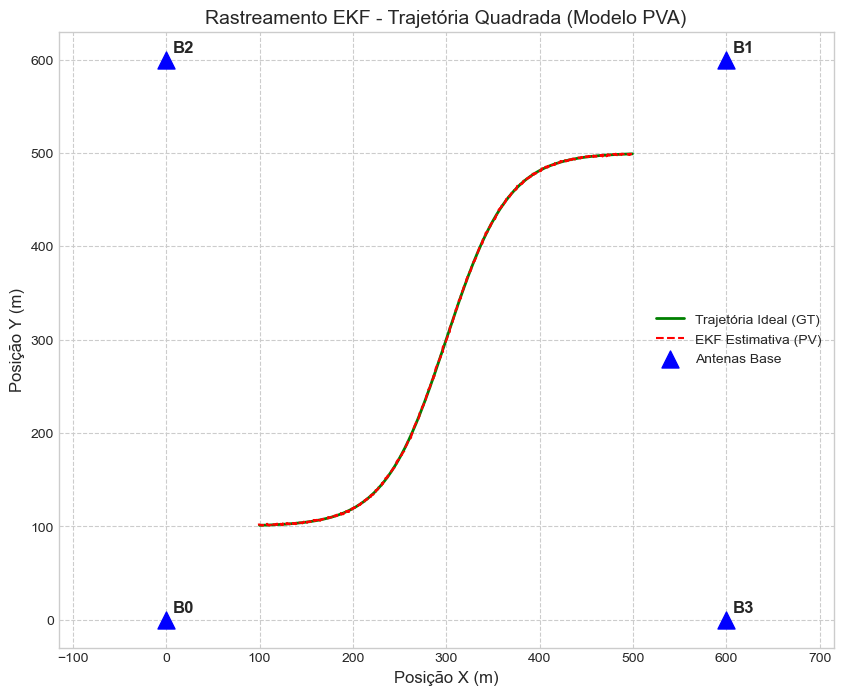

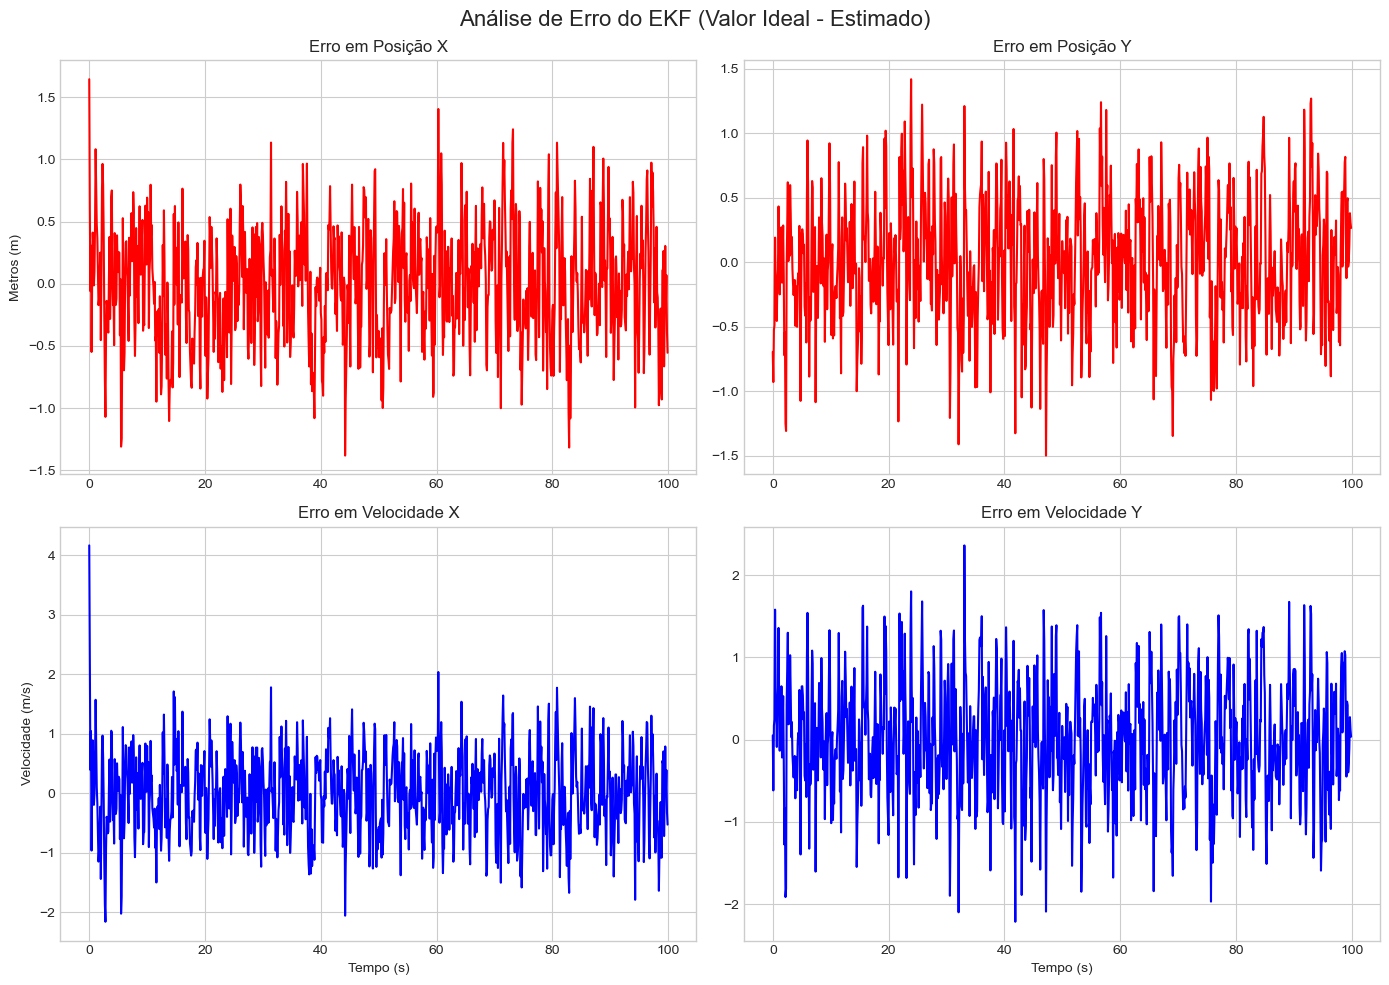

Erro médio quadrático:  0.3764203000845733


In [600]:
# ====================================================================
# 3. LOOP DE SIMULAÇÃO E RASTREAMENTO
# ====================================================================
for k in range(num_steps):
    # a) Simulação da medição real (Extraímos a distância ideal e adicionamos ruído)
    # Criamos um vetor coluna com o estado real no instante k
    x_real_k = np.array([[px_gt[k]], [py_gt[k]], [vx_gt[k]], [vy_gt[k]],[ax_gt[k]], [ay_gt[k]]])
    pos = np.array([[px_gt[k]], [py_gt[k]]])
    
    # Usamos a sua função matemática para calcular as distâncias exatas h(x)
    hx_real, _ = calc_h_and_H_PVA(x_real_k, antenas_base)
    
    # Injetamos ruído para simular o sensor Z real
    # Recuperando o vetor de erros aleatórios (4x1)
    v_t = get_noise_vec(R)
    
    # Medição final ruidosa (transpondo pos para broadcasting)
    z_medido = h_obs(pos.T, bases) + v_t

    # b) Execução do Filtro de Kalman
    ekf_pva.predict()
    ekf_pva.update(z_medido, antenas_base)
    
    # c) Salvando o estado estimado (achatando de (4,1) para (4,))
    estados_estimados[k, :] = ekf_pva.x.flatten()



# Extraindo as estimativas para variáveis isoladas
px_est = estados_estimados[:, 0]
py_est = estados_estimados[:, 1]
vx_est = estados_estimados[:, 2]
vy_est = estados_estimados[:, 3]

# ====================================================================
# 4. PLOTAGEM E CÁLCULO DE ERROS
# ====================================================================
# Cálculo dos erros (Ground Truth - Estimado)
erro_px = px_gt - px_est
erro_py = py_gt - py_est
erro_vx = vx_gt - vx_est
erro_vy = vy_gt - vy_est

# Plot 1: Trajetória 2D
plt.figure(figsize=(10, 8))
plt.plot(px_gt, py_gt, label='Trajetória Ideal (GT)', color='green', linewidth=2)
plt.plot(px_est, py_est, label='EKF Estimativa (PV)', color='red', linestyle='dashed')
plt.scatter(antenas_base[:, 0], antenas_base[:, 1], c='blue', marker='^', s=150, label='Antenas Base')
for i, (bx, by) in enumerate(antenas_base):
    plt.annotate(f'B{i}', (bx, by), xytext=(5, 5), textcoords='offset points', fontsize=12, fontweight='bold')

plt.title('Rastreamento EKF - Trajetória Quadrada (Modelo PVA)', fontsize=14)
plt.xlabel('Posição X (m)', fontsize=12)
plt.ylabel('Posição Y (m)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--')
plt.axis('equal')
plt.show()

# Plot 2: Análise de Erros nos Estados
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análise de Erro do EKF (Valor Ideal - Estimado)', fontsize=16)

# Posição X
axs[0, 0].plot(t_sq, erro_px, color='red')
axs[0, 0].set_title('Erro em Posição X', fontsize=12)
axs[0, 0].set_ylabel('Metros (m)')
axs[0, 0].grid(True)

# Posição Y
axs[0, 1].plot(t_sq, erro_py, color='red')
axs[0, 1].set_title('Erro em Posição Y', fontsize=12)
axs[0, 1].grid(True)

# Velocidade X
axs[1, 0].plot(t_sq, erro_vx, color='blue')
axs[1, 0].set_title('Erro em Velocidade X', fontsize=12)
axs[1, 0].set_xlabel('Tempo (s)')
axs[1, 0].set_ylabel('Velocidade (m/s)')
axs[1, 0].grid(True)

# Velocidade Y
axs[1, 1].plot(t_sq, erro_vy, color='blue')
axs[1, 1].set_title('Erro em Velocidade Y', fontsize=12)
axs[1, 1].set_xlabel('Tempo (s)')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

# RMS
erro = erro_px + erro_py
erro2 = np.square(erro)
rms = np.mean(erro2)

print("Erro médio quadrático: ", rms)